In [260]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, RobustScaler
from scipy.stats import normaltest
from scipy.stats import shapiro, anderson, kstest
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import boxcox
import time
import math

In [261]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
import tqdm as tqdm
import pyswarms as ps
from itertools import product
import shap

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data Collection

## Dimensi Penyusun Indeks Kebahagiaan (BPS)

### Dimensi Kepuasan Hidup
#### Dimensi Kepuasan Hidup Personal
> Indikator 
- Pendidikan dan Keterampilan [R505]
- Pekerjaan/Usaha/Kegiatan Utama [R601B2/R605]
- Pendapatan Rumah Tangga [610]
- Kesehatan [R708]
- Kondisi Rumah dan Fasilitas Rumah [R1211]
#### Dimensi Kepuasan Hidup Sosial
> Indikator 
- Keharmonisan Keluarga [R802]
- Ketersediaan Waktu Luang [R903]
- Hubungan Sosial [R1005]
- Keaadaan Lingkungan [R1102]
- Kondisi Keamanan [R1108]

### Dimensi Perasaan
> Indikator
- Perasaaan Senang/Riang/Gembira [R1302]
- Perasaan Tidak Khawatir/Cemas [R1304]
- Perasaan Tidak Tertekan [R1306]

### Dimensi Makna Hidup
> Indikator 
- Kemandirian [R1402]
- Penguasaan Lingkungan [R1404]
- Pengembangan Diri [R1406]
- Hubungan Positif dengan Orang Lain [R1408]
- Tujuan Hidup [R1410]
- Penerimaan Diri [R1412]


> __Indikator Diatas yang akan digunakan dalam perhitungan Indeks Kebahagiaan__


## Validasi Rumus Penentuan Indeks Kebahagiaan

In [262]:
df=pd.read_csv('../data/dataset.csv')

In [263]:
# Menghitung index pendidikan dan keterampilan
index_pk= (df['R505'] * df['WEIGHT']).sum() / df['WEIGHT'].sum()
index_pk= round(index_pk * 10, 2)

# Menghitung index Pekerjaan/Usaha/Kegiatan Utama
index_puku= ((df.apply(lambda row: row['R605'] if row['R601A'] == 1 else row['R601B2'], axis=1)) * df['WEIGHT']).sum() / df['WEIGHT'].sum()
index_puku= round(index_puku * 10, 2)

# Menghitung Index Pendapatan Rumah Tangga
index_prt= (df['R610'] * df['WEIGHT']).sum() / df['WEIGHT'].sum()
index_prt= round(index_prt * 10, 2)

# Menghitung Index Kesehatan
index_kes= (df['R708'] * df['WEIGHT']).sum() / df['WEIGHT'].sum()
index_kes= round(index_kes * 10, 2)

# Menghitung Index Kondisi Rumah dan Fasilitas Rumah
index_krfr= (df['R1211'] * df['WEIGHT']).sum() / df['WEIGHT'].sum()
index_krfr= round(index_krfr * 10, 2)

# Menghitung Index Keharmonisan Keluarga X
index_kkl= (df['R802'] * df['WEIGHT']).sum() / df['WEIGHT'].sum()
index_kkl= round(index_kkl * 10, 2)

# Menghitung Index Ketersediaan Waktu Luang
index_kwl= (df['R903'] * df['WEIGHT']).sum() / df['WEIGHT'].sum()
index_kwl= round(index_kwl * 10, 2)

# Menghitung Index Hubungan Sosial
index_hs= (df['R1005'] * df['WEIGHT']).sum() / df['WEIGHT'].sum()
index_hs= round(index_hs * 10, 2)

# Menghitung Index Keadaan Lingkungan
index_kl= (df['R1102'] * df['WEIGHT']).sum() / df['WEIGHT'].sum()
index_kl= round(index_kl * 10, 2)

# Menghitung Index Kondisi Keamanan
index_kk= (df['R1108'] * df['WEIGHT']).sum() / df['WEIGHT'].sum()
index_kk= round(index_kk * 10, 2)

# Menghitung Index Perasaan Senang/Riang/Gembira
index_psrg= (df['R1302'] * df['WEIGHT']).sum() / df['WEIGHT'].sum()
index_psrg= round(index_psrg * 10, 2)

# Menghitung Index Perasaan Tidak Khawatir/Cemas X
index_ptkc = 10 - (df['R1304'] * df['WEIGHT']).sum() / df['WEIGHT'].sum()
index_ptkc = round(index_ptkc * 10, 2)

# Menghitung Index Perasaan Tidak Tertekan X
index_ptt = 10 - (df['R1306'] * df['WEIGHT']).sum() / df['WEIGHT'].sum()
index_ptt = round(index_ptt * 10, 2)

# Menghitung Index Kemandirian
index_k= (df['R1402'] * df['WEIGHT']).sum() / df['WEIGHT'].sum()
index_k= round(index_k * 10, 2)

# Menghitung Index Penguasaan Lingkungan
index_pl= (df['R1404'] * df['WEIGHT']).sum() / df['WEIGHT'].sum()
index_pl= round(index_pl * 10, 2)

# Menghitung Index Pengembangan Diri
index_pbd= (df['R1406'] * df['WEIGHT']).sum() / df['WEIGHT'].sum()
index_pbd= round(index_pbd * 10, 2)

# Menghitung Index Hubungan Positif dengan Orang Lain
index_hp= (df['R1408'] * df['WEIGHT']).sum() / df['WEIGHT'].sum()
index_hp= round(index_hp * 10, 2)

# Menghitung Index Tujuan Hidup
index_th= (df['R1410'] * df['WEIGHT']).sum() / df['WEIGHT'].sum()
index_th= round(index_th * 10, 2)

# Menghitung Index Penerimaan Diri
index_pd= (df['R1412'] * df['WEIGHT']).sum() / df['WEIGHT'].sum()
index_pd= round(index_pd * 10, 2)


In [264]:
print('Index Pendidikan dan Keterampilan:', index_pk)
print('Index Pekerjaan/Usaha/Kegiatan Utama:', index_puku)
print('Index Pendapatan Rumah Tangga:', index_prt)
print('Index Kesehatan:', index_kes)
print('Index Kondisi Rumah dan Fasilitas Rumah:', index_krfr)
print('Index Keharmonisan Keluarga:', index_kkl)
print('Index Ketersediaan Waktu Luang:', index_kwl)
print('Index Hubungan Sosial:', index_hs)
print('Index Keadaan Lingkungan:', index_kl)
print('Index Kondisi Keamanan:', index_kk)
print('Index Perasaan Senang/Riang/Gembira:', index_psrg)
print('Index Perasaan Tidak Khawatir/Cemas:', index_ptkc)
print('Index Perasaan Tidak Tertekan:', index_ptt)
print('Index Kemandirian:', index_k)
print('Index Penguasaan Lingkungan:', index_pl)
print('Index Pengembangan Diri:', index_pbd)
print('Index Hubungan Positif dengan Orang Lain:', index_hp)
print('Index Tujuan Hidup:', index_th)
print('Index Penerimaan Diri:', index_pd)

Index Pendidikan dan Keterampilan: 62.79
Index Pekerjaan/Usaha/Kegiatan Utama: 72.37
Index Pendapatan Rumah Tangga: 66.76
Index Kesehatan: 76.28
Index Kondisi Rumah dan Fasilitas Rumah: 73.64
Index Keharmonisan Keluarga: 82.56
Index Ketersediaan Waktu Luang: 75.87
Index Hubungan Sosial: 79.1
Index Keadaan Lingkungan: 81.56
Index Kondisi Keamanan: 81.2
Index Perasaan Senang/Riang/Gembira: 77.64
Index Perasaan Tidak Khawatir/Cemas: 57.91
Index Perasaan Tidak Tertekan: 64.87
Index Kemandirian: 73.56
Index Penguasaan Lingkungan: 74.52
Index Pengembangan Diri: 66.09
Index Hubungan Positif dengan Orang Lain: 72.16
Index Tujuan Hidup: 75.33
Index Penerimaan Diri: 76.15


In [265]:
# masukan kedalam dataframe
# nilai peninmbang di dapatkan dari laporan BPS berdasarkan hasil perhitungan sebaran data menggunakan metode statistik yaitu ExploratoryFactor Analysis (EFA) dengan Principal Component Analysis (PCA) sebagaimetode ekstraksi faktornya. Dengan demikian, besarnya penimbang setiap dimensi, sub dimensi, dan indikator penyusun Indeks Kebahagiaan sepenuhnya dihitung berdasarkan model statistik yang dihasilkan dari pengolahan data empiris hasil survei.
# Tabel 2.1. Halaman 32

df_index = pd.DataFrame({
    'Index': ['Pendidikan dan Keterampilan', 'Pekerjaan/Usaha/Kegiatan Utama', 'Pendapatan Rumah Tangga', 'Kesehatan', 'Kondisi Rumah dan Fasilitas Rumah', 'Keharmonisan Keluarga', 'Ketersediaan Waktu Luang', 'Hubungan Sosial di Lingkungan', 'Keadaan Lingkungan', 'Kondisi Keamanan', 'Perasaan Senang/Riang/Gembira', 'Perasaan Tidak Khawatir/Cemas', 'Perasaan Tidak Tertekan', 'Kemandirian', 'Penguasaan Lingkungan', 'Pengembangan Diri', 'Hubungan Positif dengan Orang Lain', 'Tujuan Hidup', 'Penerimaan Diri'],
    'Index Value': [index_pk, index_puku, index_prt, index_kes, index_krfr, index_kkl, index_kwl, index_hs, index_kl, index_kk, index_psrg, index_ptkc, index_ptt, index_k, index_pl, index_pbd, index_hp, index_th, index_pd],
    'Penimbang': [18.34,21.67,22.81,17.04,20.14,19.41,18.93,22.13,20.64,18.89,25.86,36.80,37.34,16.56,18.44,15.27,15.48,17.48,16.78]
})
df_index

,Index,Index Value,Penimbang
0,Pendidikan dan Keterampilan,62.79,18.34
1,Pekerjaan/Usaha/Kegiatan Utama,72.37,21.67
2,Pendapatan Rumah Tangga,66.76,22.81
3,Kesehatan,76.28,17.04
4,Kondisi Rumah dan Fasilitas Rumah,73.64,20.14
5,Keharmonisan Keluarga,82.56,19.41
6,Ketersediaan Waktu Luang,75.87,18.93
7,Hubungan Sosial di Lingkungan,79.10,22.13
8,Keadaan Lingkungan,81.56,20.64
9,Kondisi Keamanan,81.20,18.89


![image.png](attachment:image.png)

In [266]:
# Index Kepuasan Hidup Personal
filter_khp = df_index['Index'].isin([
	'Pendidikan dan Keterampilan',
	'Pekerjaan/Usaha/Kegiatan Utama',
	'Pendapatan Rumah Tangga',
	'Kesehatan',
	'Kondisi Rumah dan Fasilitas Rumah',
])
index_khp = (df_index[filter_khp]['Index Value'] * df_index[filter_khp]['Penimbang']).sum() / df_index[filter_khp]['Penimbang'].sum()
index_khp = round(index_khp, 2)

# Index Kepuasan Hidup Sosial
filter_khs = df_index['Index'].isin([
	'Keharmonisan Keluarga',
	'Ketersediaan Waktu Luang',
	'Hubungan Sosial di Lingkungan',
	'Keadaan Lingkungan',
	'Kondisi Keamanan',
])
index_khs = (df_index[filter_khs]['Index Value'] * df_index[filter_khs]['Penimbang']).sum() / df_index[filter_khs]['Penimbang'].sum()
index_khs = round(index_khs, 2)

# Index Kepuasan Hidup
index_kh = (index_khp * 0.5 + index_khs * 0.5)
index_kh = round(index_kh, 2)

# Index Perasaan
filter_p = df_index['Index'].isin([
	'Perasaan Senang/Riang/Gembira',
	'Perasaan Tidak Khawatir/Cemas',
	'Perasaan Tidak Tertekan',
])
index_p = (df_index[filter_p]['Index Value'] * df_index[filter_p]['Penimbang']).sum() / df_index[filter_p]['Penimbang'].sum()
index_p = round(index_p, 2)

# Index Makna Hidup
filter_mh = df_index['Index'].isin([
	'Kemandirian',
	'Penguasaan Lingkungan',
	'Pengembangan Diri',
	'Hubungan Positif dengan Orang Lain',
	'Tujuan Hidup',
	'Penerimaan Diri',
])
index_mh = (df_index[filter_mh]['Index Value'] * df_index[filter_mh]['Penimbang']).sum() / df_index[filter_mh]['Penimbang'].sum()
index_mh = round(index_mh, 2)

# Index Kebahagiaan
index_kb = (index_kh * 0.348 + index_p * 0.3118 + index_mh * 0.3402)
index_kb = round(index_kb, 2)

In [267]:
print('Index Kepuasan Hidup Personal:', index_khp)
print('Index Kepuasan Hidup Sosial:', index_khs)
print('Index Kepuasan Hidup:', index_kh)
print('Index Perasaan:', index_p)
print('Index Makna Hidup:', index_mh)
print('Index Kebahagiaan:', index_kb)

Index Kepuasan Hidup Personal: 70.26
Index Kepuasan Hidup Sosial: 80.06
Index Kepuasan Hidup: 75.16
Index Perasaan: 65.61
Index Makna Hidup: 73.12
Index Kebahagiaan: 71.49


gambar

# Penentuan Target Indeks Kebahagiaan

In [268]:
# drop kolom yang tidak termasuk feature
# Kolom kolom tersebut merupakan detail mengenai keluarga responden, seperti jumlah anggota, alamat, status di keluarga dan lama tinggal
df.drop(['R101','R101_NAMA','R105','R108','R111','R201','R201A','R201B','B4K1','B4K3','B4K4','B4K5','B4K6','B4K7','LAMA_TINGG','R1501', 'R1502'], axis=1, inplace=True)
df.shape	

(74684, 276)

In [269]:
# membuat kolom baru dari kolom R605 berdasarkan R601A = 1 atau R601B2 berdasarkan R601A = 2
df['IPUKU'] = np.where(df['R601A'] == 1, df['R605'], df['R601B2'])

In [270]:
# Menghitung Index Kepuasan Hidup Personal
df['index_khp'] = round((
    df['R505'] * 0.1834 +
    df['IPUKU'] * 0.2167 +
    df['R610'] * 0.2281 +
    df['R708'] * 0.1704 +
    df['R1211'] * 0.2014
) * 10 , 2)

# Menghitung Index Kepuasan Hidup Sosial
df['index_khs'] = round((
    df['R802'] * 0.1941 +
    df['R903'] * 0.1893 +
    df['R1005'] * 0.2213 +
    df['R1102'] * 0.2064 +
    df['R1108'] * 0.1889
) * 10 , 2)

# Menghitung Index Kepuasan Hidup
df['index_kh'] = round((
    df['index_khp'] * 0.5 +
    df['index_khs'] * 0.5
), 2)

# Menghitung Index Perasaan
df['index_p'] = round((
    df['R1302'] * 0.2586 +
    df['R1304'] * 0.3680 +
    df['R1306'] * 0.3734
) * 10 , 2)

# Menghitung Index Makna Hidup
df['index_mh'] = round((
    df['R1402'] * 0.1656 +
    df['R1404'] * 0.1844 +
    df['R1406'] * 0.1527 +
    df['R1408'] * 0.1548 +
    df['R1410'] * 0.1748 +
    df['R1412'] * 0.1678
) * 10 , 2)

# Menghitung Index Kebahagiaan
df['index_k'] = round((
    df['index_kh'] * 0.348 +
    df['index_p'] * 0.3118 +
    df['index_mh'] * 0.3402
), 2)


Angka yang dikalikan merupakan Penimbang yang sudah di jelaskan di bagian sebelum ini

In [271]:
df[['index_khp','index_khs', 'index_kh', 'index_p', 'index_mh', 'index_k']].describe()

,index_khp,index_khs,index_kh,index_p,index_mh,index_k
count,74684.000000,74684.000000,74684.000000,74684.000000,74684.000000,74684.000000
mean,70.455596,80.574794,75.515230,48.485026,73.527213,66.410889
std,12.748365,9.200442,9.521549,13.848781,10.414822,6.940839
min,6.040000,6.170000,10.000000,0.000000,1.750000,9.480000
25%,63.170000,75.025000,69.840000,39.090000,67.000000,62.160000
50%,71.570000,80.020000,75.810000,47.760000,73.515000,66.190000
75%,78.480000,86.170000,81.350000,57.760000,80.010000,70.500000
max,100.000000,100.000000,100.000000,100.000000,100.010000,100.000000


In [272]:
# drop kolom yang tidak diperlukan
df.drop(['R505','R601B2','R605','R610','R708','R1211','R802','R903','R1102','R1108','R1402','R1404','R1406','R1408','R1410','R1412','R1005','R1302','R1304','R1306','IPUKU','index_khp','index_khs', 'index_kh', 'index_p', 'index_mh'], axis=1, inplace=True)

In [273]:
df.shape

(74684, 257)

# Data Prepocessing

## handling Missing Value

In [274]:
missing = df.isnull().sum()
print("\nJumlah Missing Values:")
missing[missing > 0]


Jumlah Missing Values:


R1601A       1067
R1601B       1067
R1604B      13133
R1607B      16669
R1608B      53025
            ...  
R1103FK7    74230
R1103GK7    74230
R1103HK7    74230
R1103IK7    74230
R1103JK7    74292
Length: 99, dtype: int64

### Kolom Kategorical

#### kolom R1607B, R1608C, R1609C

In [275]:
def encodeData(df, column,  references):
    # Loop melalui setiap huruf dalam daftar referensi
    for i, letter in enumerate(references):
        # Nama kolom baru akan menjadi R1607B_Huruf (misal: R1607B_A, R1607B_B)
        # Menggunakan f-string untuk membuat nama kolom dinamis
        # Menggunakan underscore untuk keterbacaan
        column_name = f'{column}_{letter}'
        df[column_name] = df[column].apply(
            lambda x: 0 if pd.isna(x) else (1 if letter in str(x) else 0)
        )
        
# Referensi huruf
references = ['A', 'B', 'C', 'D', 'E', 'F', 'X'] # untuk kolom R1607B
references2 = ['A', 'B', 'C', 'D', 'E', 'F'] # untuk kolom R1608C, R1609C

encodeData(df, 'R1607B', references)
encodeData(df, 'R1608C', references2)
encodeData(df, 'R1609C', references2)

df.loc[df['R1607A'].isin([4,5]), ['R1607B','R1607B_A', 'R1607B_B', 'R1607B_C', 'R1607B_D', 'R1607B_E', 'R1607B_F', 'R1607B_X']].head()

,R1607B,R1607B_A,R1607B_B,R1607B_C,R1607B_D,R1607B_E,R1607B_F,R1607B_X
4,D,0,0,0,1,0,0,0
5,B,0,1,0,0,0,0,0
6,C,0,0,1,0,0,0,0
7,D,0,0,0,1,0,0,0
8,D,0,0,0,1,0,0,0


In [276]:
df[[
	'R1607B', 'R1607B_A', 'R1607B_B', 'R1607B_C', 'R1607B_D', 'R1607B_E', 'R1607B_F', 'R1607B_X',
	'R1608C','R1608C_A', 'R1608C_B', 'R1608C_C', 'R1608C_D', 'R1608C_E', 'R1608C_F', 
	'R1609C', 'R1609C_A', 'R1609C_B', 'R1609C_C', 'R1609C_D', 'R1609C_E', 'R1609C_F'
]].isnull().sum()[lambda x: x > 0]

R1607B    16669
R1608C    21659
R1609C    48158
dtype: int64

In [277]:
#  drop column yang tidak terpakai
df.drop(columns=['R1607B', 'R1608C', 'R1609C'], inplace=True)

#### kolom R702B (data penyakit)

In [278]:
# Kategori penyakit yang sudah disiapkan
categories = {
    "Penyakit Jantung dan Pembuluh Darah": ["sering pingsan tiba-tiba","pembekakan pembuluh darah","penyumbatan pembuluh darah","tensi","darah rendah","drop darah","penyempitan pembuluh darah","tensi tinggi","kurtosis aorta", "jantung", "koroner", "hipertensi", "tekanan darah tinggi","darah tinggi", "aritmia", "gagal jantung","penyumbatan darah"],
    "Penyakit Sistem Pernafasan": ["paru","afses paru","paru-paru","rinitis","faringitis","meniere syndrome","ispa","radang nasofaring","osa","nafas pendek","alergi dingin","tb","infeksi hidung","alergi asap","radang tenggorokan","covid","saluran pernafasan","peradangan paru","alergi debu","penyempitan pernafasan","tbc","sinusitis","polip", "amandel","step","tipes","sesak","sinositis","sesak nafas","asma", "bronkitis", "pneumonia", "copd"],
    "Penyakit Metabolik": ["kekurangan kalium","anemia","kencing manis","lemak darah","diabetes", "diabetes melitus", "kolesterol", "asam urat", "gout", "hiperlipidemia","gula darah","gula"],
    "Penyakit Tulang, Otot, dan Sendi": ["bengkak otot","kaki","avn","hnp","luka di kaki","kaki  terluka","pincang","otot bahu","kaki terluka","kolagen","cacat kaki","radang otot kaki","osteoarthrotis","punggung","kaki mudah merasa lemas","kaki selalu terasa lemas","hernea","sendi","gangguan persendian","kelelahan otot", "di bagin kaki","kesulitan untuk berjalan", "cacat pincang", "osteoritis","radang sendi","lutut","pengapuran","pinggang", "tulang", "hernia","patah kaki","osteoporosis", "artritis", "skoliosis", "fibromyalgia", "rematik"],
    "Penyakit Kanker dan Tumor": ["pembengkakan payudara","leukimia","kangker payudara","kista","kanker", "melanoma", "tumor","kangker perut"],
    "Penyakit Sistem Pencernaan": ["bagian perut","perut bengkak ( ada genangan air dlm perut )","pencernaan","berak darah","muntah darah","gangguan pencernaan","infeksi saluran pencernaan","empedu","refluks gastroesofagus","usus turung","pencernaan usus","gangguan empedu","kram usus", "liver","susah buang air besar", "radang usus", "empedu mengandung lemak dan lumpur","alergi saluran pencernaan","infeksi usus","tifus","peti liver","kuning","ambeyen", "hati","asam lambung","lambung", "maag", "gastritis", "batu empedu", "hepatitis", "ibs","usus buntu","gangguan usus"],
    "Penyakit Mata": ["ablosio retina", "tuna netra", "mata","katarak", "glaukoma", "konjungtivitis", "degenerasi makula", "buta","rabun"],
    "Penyakit Ginjal dan Saluran Kemih": ["kencing tidak lancar","infeksi saluran kemih","radang kencing","penyempitan saluran ginjal","gangguan saluran kencing","kencing batu","kencing frostat","ginjal", "batu ginjal", "isk", "gagal ginjal", "nefritis","infeksi saluran kencing"],
    "Penyakit Sistem Saraf dan Kejiwaan": ["pencairan di otak","jiwa","meningitis","tremor","gangguan jiwa","bisu","kejang","saraf terjepit","tekanan jiwa","kepala", "migrain","insomnia", "encephalitis","susah tidur", "vertigo","saraf","penyempitan saraf","epilepsi", "skizofrenia", "stroke", "depresi","mental","lumpuh","kejiwaan"],
    "Lainnya": ["kurang kalsium", "theroid","tiroid","teroid","hiperteroid","kelenjar","gondok","gondog","komplikasi","malaria","prostat","tiroit","autoimun","infeksi kulit yg parah","ada miom di rahim","keguguran","kelainan fisik","telinga pokak","kurang pendengaran","kelenjar leher","kaki bengkak spt kaki gajah  hanya saja bukan  kaki gajah","radang payudara","kulit","trauma menyeluruh","endometriosis","beri-beri","endometriosis","benjolan di leher","benjolan dileher","batuk","endrometriosis","prostat","porstat","tahunan","sel darah putih","miom habis operasi 6 bulan yllu","exim","maaf kronis","eksim","demam panas","dalam","terahum","pengangkatan rahim","kehamilan abdomen","kusta basah","gatal-gatal yang tidak bisa sembuh","virus tokso dinyatakan oleh dokter bahaya jika kalau hamil","hidroteroit","bulanan tidak normal","miyoma","miyoum","mioma","hypertirod","alergi semen","alergi","takanan","kronis","typoid","miom","kelebihan hormon","tekanan","pengobatan 6 bulan","payudara","gatal gatal","tidak bisa jalan","tua tdk bs jalan","dikarenakan umur yg sudah tua"],
}

# Fungsi memuat peta kesalahan ketik (typo_map)
def load_typo_map(file_path):
    typo_map = {}
    with open(file_path, 'r') as file:
        for line in file:
            typo, correct = line.strip().split('|')
            typo_map[typo] = correct
    return typo_map

# Muat peta kesalahan ketik
typo_map = load_typo_map('../data/typo_map.txt')

# Fungsi normalisasi teks dengan memperbaiki typo menggunakan typo_map
def normalize_text(text, typo_map):
    # Pertama, ganti typo berdasarkan typo_map
    text = text.lower()
    for typo, correct in typo_map.items():
        text = text.replace(typo, correct)
    
    # Lakukan normalisasi lainnya
    return text.replace(" dan ", ",").replace("&", ",").replace("/", ",").replace(".", " ").strip()

# Fungsi pemrosesan baris data untuk kategorisasi penyakit
def process_row(entry, typo_map, categories):
    normalized_entry = normalize_text(entry, typo_map)
    normalized_diseases = [disease.strip() for disease in normalized_entry.split(",")]

    
    # Pemetaan kategori untuk setiap penyakit
    result = {category: 0 for category in categories.keys()}  # Default 0 (tidak)
    result['normalize_R702B'] = normalized_entry
    for disease in normalized_diseases:
        for category, keywords in categories.items():
            if any(keyword in disease for keyword in keywords):
                result[category] = 1  # 1 (ya)
    
    return result

# Fungsi utama untuk memproses dan menambahkan hasil ke df_combined
def process_and_add_to_df(df_combined, typo_map, categories):
    results = []

    # Proses setiap baris pada df_combined berdasarkan 'R702A' == "1"
    for entry in df_combined.loc[df_combined['R702A'] == 1, 'R702B']:
        result = process_row(entry, typo_map, categories)
        results.append(result)

    # Buat DataFrame hasil
    df_results = pd.DataFrame(results)

    # Kolom yang akan ditambahkan ke df_combined adalah hasil kategori R702A1 hingga R702A11
    df_combined_results = df_combined.loc[df_combined['R702A'] == 1].copy()

    # Menambahkan hasil kategori ke df_combined_results
    df_combined_results = df_combined.loc[df_combined['R702A'] == 1].copy().reset_index(drop=True)
    df_results = df_results.drop(columns=["normalize_R702B"])
    df_results = df_results.reset_index(drop=True)
    for i, column in enumerate(df_results.columns):
        new_column_name = f"R702B_{i+1}"
        df_combined_results[new_column_name] = df_results[column]

    # Menambahkan kolom R702B_1 hingga R702B_11 dengan nilai default 0 untuk baris lainnya
    for i in range(1, len(categories.keys()) + 1):
        column_name = f"R702B_{i}"
        if column_name not in df_combined.columns:
            df_combined[column_name] = 0

    # Gabungkan kembali dengan data df_combined
    df_combined_others = df_combined[df_combined['R702A'] != 1].copy()
    df_combined_final = pd.concat([df_combined_others, df_combined_results], ignore_index=True)

    return df_combined_final



# Proses dan tambahkan ke df_combined
df = process_and_add_to_df(df, typo_map, categories)
print(df.shape)

(74684, 283)


In [279]:
missing_values = df[['R702B_1', 'R702B_2', 'R702B_3', 'R702B_4', 'R702B_5', 'R702B_6', 'R702B_7', 'R702B_8', 'R702B_9', 'R702B_10']].isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values

Series([], dtype: int64)

In [280]:
# drop column yang tidak terpakai
df.drop(columns=['R702B'], inplace=True)

### sisa missing value

In [281]:
missing = df.isnull().sum()
print("\nJumlah Missing Values:")
missing[missing > 0]


Jumlah Missing Values:


R1601A       1067
R1601B       1067
R1604B      13133
R1608B      53025
R1609B1     25207
            ...  
R1103FK7    74230
R1103GK7    74230
R1103HK7    74230
R1103IK7    74230
R1103JK7    74292
Length: 95, dtype: int64

In [282]:
df_filled_with_mode = df.apply(lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x)

In [283]:
missing = df_filled_with_mode.isnull().sum()
print("\nJumlah Missing Values:")
missing[missing > 0]


Jumlah Missing Values:


Series([], dtype: int64)

In [284]:
numeric_cols = df_filled_with_mode.select_dtypes(include='number').columns
numeric_cols = [col for col in numeric_cols if col not in ['URUT', 'WEIGHT']]
for kolom in numeric_cols:
	data = df_filled_with_mode[kolom]
	if data.max() == data.min():
		print(kolom)

R1103FK6


In [285]:
df_filled_with_mode['R1103FK6'].describe()

count    74684.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: R1103FK6, dtype: float64

In [286]:
# data di drop karena tidak memiliki variansi atau std = 0
df_filled_with_mode.drop(['R1103FK6'], axis=1, inplace=True)

#### Shapiro-Wilk Test

## Encoding

In [287]:
df_encode = df_filled_with_mode.copy()
# Data dipisah setiap jenis data
kolom_kategorikal_nominal = [ # data yang tidak memiliki hirarki, misal tempat bekerja => 1. petani, 2. nelayan, 4. karyawan dll
    "R601B1", "R602A1", "R602A2", "R703B", "R902C", "R1201", "R1205", "R1608B", "R1613B",
    'R1103BK2', 'R1103BK3', 'R1103BK4', 'R1103BK5', 'R1103BK6', 'R1103BK7', 
	'R1103DK2', 'R1103DK3', 'R1103DK4', 'R1103DK5', 'R1103DK6', 'R1103DK7', 
	'R1103FK2', 'R1103FK3', 'R1103FK4', 'R1103FK5', 'R1103FK7', 
	'R1103GK2', 'R1103GK3', 'R1103GK4', 'R1103GK5', 'R1103GK6', 'R1103GK7', 
	'R1103JK2', 'R1103JK3', 'R1103JK4', 'R1103JK5', 'R1103JK6', 'R1103JK7'
]

kolom_kategorikal_ordinal = [ # data yang memiliki tingkatan dalam nilai nya, misal pendidikan => 1. Sd, 3. Smp dll
    "R501", "R504A", "R504B", "R504C", "R603", "R606", "R607", "R609A", "R609B", "R609C", "R701A", "R701B",
    "R704A", "R704B", "R704C", "R704D", "R704E", "R704F", "R704G", "R704H",
    "R706A", "R706B", "R706C", "R706D", "R706E", "R706F", "R706G", "R706H", "R706I", "R706J", "R707A", "R707B", "R707C",
    "R801A", "R801B", "R801C", "R801D", "R1001A", "R1001B", "R1001C", "R1101C", "R1104A", "R1104B", "R1104C", "R1105",
    "R1106A", "R1106B", "R1107A", "R1107B", "R1203", "R1204", "R1206A", "R1206B", "R1207", "R1208", "R1209",
    "R1301A", "R1301B", "R1301C", "R1303A", "R1303B", "R1303C", "R1305A", "R1305B", "R1305C", "R1305D",
    "R1401A", "R1401B", "R1401C", "R1401D", "R1403A", "R1403B", "R1403C", "R1405A", "R1405B", "R1405C",
    "R1407A", "R1407B", "R1409A", "R1411A", "R1411B", "R1411C", "R1602", "R1603", "R1604B",
    "R1605A", "R1605B", "R1605C", "R1605D", "R1605E", "R1606", "R1607A", "R1610", "R1611", "R1612",
    "R1613A", "R1613C", "R1614", "R1615", "R1616"
]

kolom_biner = [ # memiliki 2 nilai, 1 dan 2
    "R502", "R503", "R601A", "R602B", "R604A", "R604B", "R604C", "R604D", "R604E", "R604F", "R604G", "R608",
    "R702A", "R703A1", "R703A2", "R705A", "R705B1", "R705B2", "R705B3", "R705B4", "R705B5", "R705B6", "R902B1",
    "R902B2", "R902B3", "R902B4", "R902B5", "R1101A1", "R1101A2", "R1101A3", "R1101A4", "R1101A5", "R1101B1",
    "R1101B2", "R1101B3", "R1210A", "R1210B", "R1210C", "R1210D", "R1210E", "R1409B", "R1604A", "R1608A", "R1609A",
    "R1609B1", "R1609B2", "R1609B3", "R1609B4", "R1609B5", "R1609B6",
    'R1103AK2', 'R1103AK3', 'R1103AK4', 'R1103AK5', 'R1103AK6', 'R1103AK7', 
	'R1103CK2', 'R1103CK3', 'R1103CK4', 'R1103CK5', 'R1103CK6', 'R1103CK7', 
	'R1103EK2', 'R1103EK3', 'R1103EK4', 'R1103EK5', 'R1103EK6', 'R1103EK7', 
	'R1103HK2', 'R1103HK3', 'R1103HK4', 'R1103HK5', 'R1103HK6', 'R1103HK7', 
	'R1103IK2', 'R1103IK3', 'R1103IK4', 'R1103IK5', 'R1103IK6', 'R1103IK7'
]

kolom_kategorikal_encoded = [ # data string/text yang telah dikategorikan dan di encode pada tahap prepcessing (sudah biner)
    "R702B_1", "R702B_2", "R702B_3", "R702B_4", "R702B_5", "R702B_6", "R702B_7", "R702B_8", "R702B_9", "R702B_10",
    'R1607B_A', 'R1607B_B', 'R1607B_C', 'R1607B_D', 'R1607B_E', 'R1607B_F', 'R1607B_X',
    'R1609C_A', 'R1609C_B', 'R1609C_C', 'R1609C_D', 'R1609C_E', 'R1609C_F',
    'R1608C_A', 'R1608C_B', 'R1608C_C', 'R1608C_D', 'R1608C_E', 'R1608C_F',
]

# nilai 1 - 10
kolomscoring = [
    "R1003A", "R1003B", "R1003C", "R1003D", "R1003E", "R1003F", "R1003G", "R1003H", "R1003I", "R1003J",
    "R1004A", "R1004B", "R1004C", "R1004D", "R1004E", "R1004F",
    "R1002A", "R1002B", "R1002C", "R1002D", "R1002E", "R1002F", "R1002G", "R1002H", "R1002I", "R1002J"
]

# kolom yang memiliki nilai nominal
kolomnominal = [
    "R1601A",
    "R1601B",
    "R902A",
    "R1202",
    "R901"
]

In [288]:
# mengubah type float menjadi int
df_encode[kolom_kategorikal_nominal] = df_encode[kolom_kategorikal_nominal].astype(int)
df_encode[kolom_kategorikal_ordinal] = df_encode[kolom_kategorikal_ordinal].astype(int)
df_encode[kolom_biner] = df_encode[kolom_biner].astype(int)
df_encode[kolom_kategorikal_encoded] = df_encode[kolom_kategorikal_encoded].astype(int)
df_encode[kolomnominal] = df_encode[kolomnominal].astype(int)
df_encode[kolomscoring] = df_encode[kolomscoring].astype(int)

### Memperbaiki Nilai Biner

In [289]:
# mengubah nilai 2 di kolom biner menjadi nol

# cek dalam kolom biner yang memiliki nilai bukan 1 dan 2
def find_binary_one_two_columns(df_):
    binary_columns = []
    for col in df_.columns:
        # Cek apakah kolom numerik
        if pd.api.types.is_numeric_dtype(df_[col]):
            unique_values = df_[col].dropna().unique()
            # Cek apakah hanya ada 1 dan 2 di nilai unik
            if set(unique_values) != {1, 2}:
                binary_columns.append(col)
    return binary_columns

kolom_biner_1_2 = find_binary_one_two_columns(df_encode[kolom_biner])
print(f"Kolom yang hanya memiliki nilai biner 1 dan 2 adalah: {kolom_biner_1_2}")

Kolom yang hanya memiliki nilai biner 1 dan 2 adalah: ['R703A2', 'R1101A1', 'R1101A2', 'R1101A3', 'R1101A4', 'R1101A5']


In [290]:
print(df_encode['R703A2'].unique())
print(df_encode['R1101A1'].unique())
print(df_encode['R1101A2'].unique())
print(df_encode['R1101A3'].unique())
print(df_encode['R1101A4'].unique())
print(df_encode['R1101A5'].unique())

[4 3]
[1 2 9]
[2 1 9]
[2 1 9]
[2 1 9]
[2 1 9]


In [291]:
# memperbaiki data bermasalah dan menggantinya dengan data modus
df_encode[['R1101A1', 'R1101A2', 'R1101A3', 'R1101A4', 'R1101A5']] = df_encode[['R1101A1', 'R1101A2', 'R1101A3', 'R1101A4', 'R1101A5']].apply(
    lambda col: col.replace(9, col.mode()[0]) if not col.mode().empty else col
)

# Mengubah nilai di kolom 'R703A2': 3 menjadi 1, dan 4 menjadi 2
df_encode['R703A2'] = df_encode['R703A2'].replace({3: 1, 4: 2})

In [292]:
kolom_biner_1_2 = find_binary_one_two_columns(df_encode[kolom_biner])
print(f"Kolom yang hanya memiliki nilai biner 1 dan 2 adalah: {kolom_biner_1_2}")

Kolom yang hanya memiliki nilai biner 1 dan 2 adalah: []


### Encod Kolom Kategorical Nominal

In [293]:
# Membuat instance OneHotEncoder
# handle_unknown='ignore' penting agar tidak error jika ada kategori baru di data testing
# sparse_output=False agar hasilnya berupa array numpy dense (bukan sparse matrix)
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# Melatih encoder dan mengubah data
# Kita perlu memilih kolom yang akan di-encode terlebih dahulu
encoded_data = encoder.fit_transform(df_encode[kolom_kategorikal_nominal])
# Mendapatkan nama-nama kolom baru
encoded_feature_names = encoder.get_feature_names_out(kolom_kategorikal_nominal)
# Membuat DataFrame dari hasil encoding
df_encoded_sklearn = pd.DataFrame(encoded_data, columns=encoded_feature_names)
# Menggabungkan hasil encoding dengan kolom non-kategorikal dari DataFrame asli
# Pertama, drop kolom kategorikal asli
df_non_categorical = df_encode.drop(columns=kolom_kategorikal_nominal)
# Gabungkan
df_final_encode = pd.concat([df_non_categorical, df_encoded_sklearn], axis=1)
df_final_encode


,URUT,R1301A,R1301B,R1301C,R1303A,R1303B,R1303C,R1305A,R1305B,R1305C,...,R1103JK6_8,R1103JK6_9,R1103JK7_1,R1103JK7_2,R1103JK7_3,R1103JK7_4,R1103JK7_5,R1103JK7_6,R1103JK7_7,R1103JK7_9
0,1,1,1,1,4,1,4,1,2,2,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,1,2,2,4,1,2,4,2,2,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,1,1,2,1,1,4,4,1,2,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,1,1,2,2,1,2,2,2,2,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,1,1,2,4,1,2,2,2,2,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74679,74600,1,1,3,1,1,2,2,2,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
74680,74618,1,1,3,1,1,1,1,2,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
74681,74671,1,2,2,3,1,3,1,2,2,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
74682,74673,1,1,3,1,1,2,1,1,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [294]:
df_final_encode.shape

(74684, 475)

## Uji Normalitas Data

### Uji Shapiro

In [295]:
normal_columns = []
all_columns = []
# Sampling 5000 baris acak
df_sampled = df_filled_with_mode.sample(n=5000, random_state=42)

for col in df_sampled.select_dtypes(include='number').columns:
    data = df_sampled[col].dropna()

    # Lewati kolom jika data kurang dari 3 atau range = 0
    if len(data) < 3 or data.max() == data.min():
        continue

    stat, p = shapiro(data)
    all_columns.append({
		'kolom': col,
		'stat': stat,
		'p_value': p
	})
    if p > 0.05:
        normal_columns.append({
			'kolom': col,
			'stat': stat,
			'p_value': p
		})

# Tampilkan dalam bentuk DataFrame
df_normal = pd.DataFrame(normal_columns)
df_all = pd.DataFrame(all_columns)
df_normal

""


In [296]:
df_all.describe()

,stat,p_value
count,267.000000,2.670000e+02
mean,0.460413,2.832448e-23
std,0.316095,4.628255e-22
min,0.003016,8.818914e-96
25%,0.162297,1.057242e-91
50%,0.500436,3.946304e-80
75%,0.743011,5.085592e-66
max,0.987262,7.562631e-21


### Kolmogorov-Smirnov (KS) Test

Dengan Semua Data

In [297]:
ks_normal_columns = []
ks_all_columns = []

for col in df_filled_with_mode.select_dtypes(include='number').columns:
    data = df_sampled[col].dropna()

    # Lewati kolom jika data kurang dari 3 atau range = 0
    if len(data) < 3 or data.max() == data.min():
        continue

    stat, p = kstest(data, 'norm')
    ks_all_columns.append({
		'kolom': col,
		'stat': stat,
		'p_value': p
	})
    if p > 0.05:
        ks_normal_columns.append({
			'kolom': col,
			'stat': stat,
			'p_value': p
		})

# Tampilkan dalam bentuk DataFrame
ks_df_normal = pd.DataFrame(normal_columns)
ks_df_all = pd.DataFrame(all_columns)
ks_df_normal

""


In [298]:
ks_df_all.describe()

,stat,p_value
count,267.000000,2.670000e+02
mean,0.460413,2.832448e-23
std,0.316095,4.628255e-22
min,0.003016,8.818914e-96
25%,0.162297,1.057242e-91
50%,0.500436,3.946304e-80
75%,0.743011,5.085592e-66
max,0.987262,7.562631e-21


### Anderson-Darling (AD) Test

In [299]:
an_normal_columns = []
an_all_columns = []

for col in df_filled_with_mode.select_dtypes(include='number').columns:
    data = df_sampled[col].dropna()

    # Lewati kolom jika data kurang dari 3 atau range = 0
    if len(data) < 3 or data.max() == data.min():
        continue

    result = anderson(data, 'norm')
    an_all_columns.append({
		'kolom': col,
		'statistic': result.statistic,
		'p_value': result.significance_level,
	})
    if result.statistic < result.critical_values[2]:
        an_normal_columns.append({
			'kolom': col,
			'statistic': result.statistic,
			'p_value': result.significance_level,
		})

# Tampilkan dalam bentuk DataFrame
an_df_normal = pd.DataFrame(normal_columns)
an_df_all = pd.DataFrame(all_columns)
an_df_normal

""


In [300]:
an_df_all.describe()

,stat,p_value
count,267.000000,2.670000e+02
mean,0.460413,2.832448e-23
std,0.316095,4.628255e-22
min,0.003016,8.818914e-96
25%,0.162297,1.057242e-91
50%,0.500436,3.946304e-80
75%,0.743011,5.085592e-66
max,0.987262,7.562631e-21


In [301]:
from scipy.stats import ttest_ind

In [302]:
# Looping untuk menghitung Cohen's d, interval kepercayaan, dan uji Levene untuk setiap grup
for group_column in kolomscoring + kolomnominal:
    group1 = df_filled_with_mode[group_column]  # Data untuk grup pertama
    target = df_filled_with_mode['index_k']  # Data untuk target (grup kedua)

    stat, p_value = ttest_ind(group1, target, equal_var=False)
    print(f"t-statistic: {stat}")
    print(f"P-value: {p_value}")

    if p_value > 0.05:
        print("Ada perbedaan yang signifikan antara grup 1 dan grup 2 (menolak H₀).")
    else:
        print("Tidak ada perbedaan yang signifikan antara grup 1 dan grup 2 (gagal menolak H₀).")
    
    print("\n" + "="*50)

t-statistic: -2242.6541296556015
P-value: 0.0
Tidak ada perbedaan yang signifikan antara grup 1 dan grup 2 (gagal menolak H₀).

t-statistic: -2241.593887844274
P-value: 0.0
Tidak ada perbedaan yang signifikan antara grup 1 dan grup 2 (gagal menolak H₀).

t-statistic: -2251.2563422855837
P-value: 0.0
Tidak ada perbedaan yang signifikan antara grup 1 dan grup 2 (gagal menolak H₀).

t-statistic: -2242.568266811623
P-value: 0.0
Tidak ada perbedaan yang signifikan antara grup 1 dan grup 2 (gagal menolak H₀).

t-statistic: -2269.9477318267386
P-value: 0.0
Tidak ada perbedaan yang signifikan antara grup 1 dan grup 2 (gagal menolak H₀).

t-statistic: -2252.5161533109617
P-value: 0.0
Tidak ada perbedaan yang signifikan antara grup 1 dan grup 2 (gagal menolak H₀).

t-statistic: -2251.6833726893315
P-value: 0.0
Tidak ada perbedaan yang signifikan antara grup 1 dan grup 2 (gagal menolak H₀).

t-statistic: -2261.254486842878
P-value: 0.0
Tidak ada perbedaan yang signifikan antara grup 1 dan grup 2 

## Memperbaiki Normalitas Data

Power Tranformation (Pada Data Nominal)

In [303]:
total_np = 0
for column in kolomnominal + kolomscoring:
    if (df_filled_with_mode[column] <= 0).any():
        total_np += 1
    else:
        print(f"Kolom {column} tidak memiliki nilai negatif atau nol.")
total_np

Kolom R1601A tidak memiliki nilai negatif atau nol.
Kolom R1202 tidak memiliki nilai negatif atau nol.


29

In [304]:
len(kolomnominal + kolomscoring)

31

In [305]:
from sklearn.preprocessing import PowerTransformer
power_transformer = PowerTransformer(method='yeo-johnson')

In [306]:
df_transformed = df_filled_with_mode.copy()

for column in kolomnominal + kolomscoring:
	df_transformed[column] = power_transformer.fit_transform(df_transformed[[column]])
df_transformed.head()

,URUT,R1301A,R1301B,R1301C,R1303A,R1303B,R1303C,R1305A,R1305B,R1305C,...,R702B_1,R702B_2,R702B_3,R702B_4,R702B_5,R702B_6,R702B_7,R702B_8,R702B_9,R702B_10
0,1,1,1,1,4,1,4,1,2,2,...,0,0,0,0,0,0,0,0,0,0
1,2,1,2,2,4,1,2,4,2,2,...,0,0,0,0,0,0,0,0,0,0
2,3,1,1,2,1,1,4,4,1,2,...,0,0,0,0,0,0,0,0,0,0
3,4,1,1,2,2,1,2,2,2,2,...,0,0,0,0,0,0,0,0,0,0
4,5,1,1,2,4,1,2,2,2,2,...,0,0,0,0,0,0,0,0,0,0


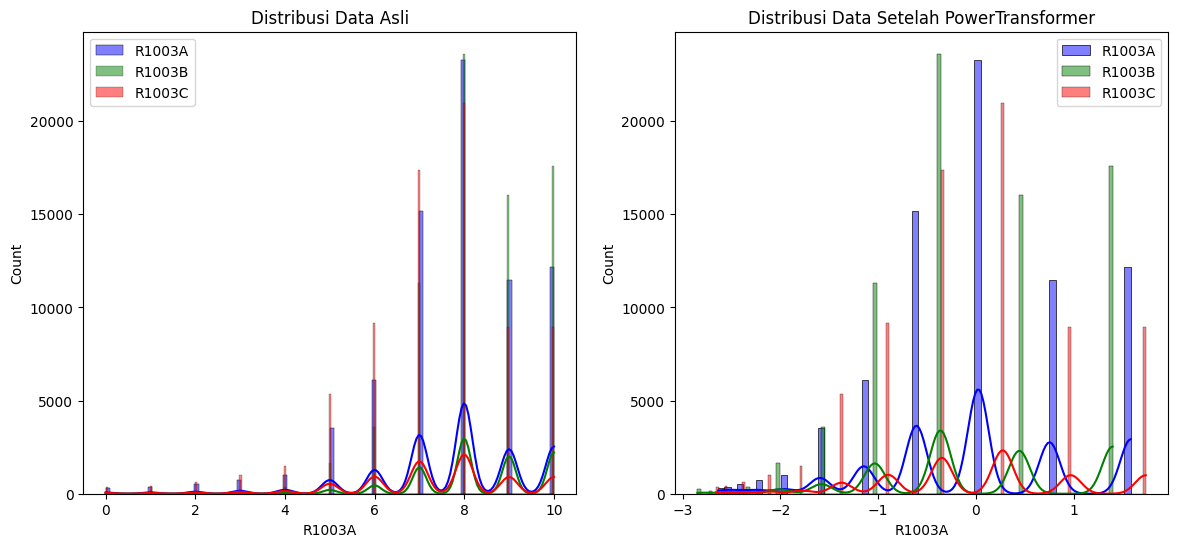

In [307]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].set_title("Distribusi Data Asli")
sns.histplot(df_filled_with_mode['R1003A'], ax=axes[0], kde=True, color='blue', label='R1003A')
sns.histplot(df_filled_with_mode['R1003B'], ax=axes[0], kde=True, color='green', label='R1003B')
sns.histplot(df_filled_with_mode['R1003C'], ax=axes[0], kde=True, color='red', label='R1003C')
axes[0].legend()

# Plot data yang sudah ditransformasi
axes[1].set_title("Distribusi Data Setelah PowerTransformer")
sns.histplot(df_transformed['R1003A'], ax=axes[1], kde=True, color='blue', label='R1003A')
sns.histplot(df_transformed['R1003B'], ax=axes[1], kde=True, color='green', label='R1003B')
sns.histplot(df_transformed['R1003C'], ax=axes[1], kde=True, color='red', label='R1003C')
axes[1].legend()

In [308]:
results = []

# Fungsi untuk melakukan Shapiro-Wilk test dan mencetak p-value
def shapiro_test(data):
    stat, p_value = shapiro(data)
    return p_value

# Menampilkan p-value untuk data asli dan data setelah transformasi
for column in kolomnominal + kolomscoring:
    p_value_original = shapiro_test(df_filled_with_mode[column])
    p_value_transformed = shapiro_test(df_transformed[column])
        # Menyimpan hasil ke dalam list
    results.append({
        'Kolom': column,
        'P-value Data Asli': p_value_original,
        'P-value Data Setelah PowerTransformer': p_value_transformed,
        'Normalitas Data Asli': 'Berdistribusi Normal' if p_value_original >= 0.05 else 'Tidak Berdistribusi Normal',
        'Normalitas Data Setelah Transformasi': 'Berdistribusi Normal' if p_value_transformed >= 0.05 else 'Tidak Berdistribusi Normal'
    })
df_results = pd.DataFrame(results)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_8252\2568353154.py:5: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 74684.
  stat, p_value = shapiro(data)


In [309]:
df_results

,Kolom,P-value Data Asli,P-value Data Setelah PowerTransformer,Normalitas Data Asli,Normalitas Data Setelah Transformasi
0,R1601A,3.909123e-117,2.665196e-66,Tidak Berdistribusi Normal,Tidak Berdistribusi Normal
1,R1601B,6.832592e-107,5.085038e-85,Tidak Berdistribusi Normal,Tidak Berdistribusi Normal
2,R902A,1.445256e-104,4.477424e-59,Tidak Berdistribusi Normal,Tidak Berdistribusi Normal
3,R1202,7.336227e-134,5.811609e-53,Tidak Berdistribusi Normal,Tidak Berdistribusi Normal
4,R901,1.198565e-57,4.997325e-50,Tidak Berdistribusi Normal,Tidak Berdistribusi Normal
5,R1003A,1.771729e-108,3.972548e-94,Tidak Berdistribusi Normal,Tidak Berdistribusi Normal
6,R1003B,3.409985e-112,7.483374e-103,Tidak Berdistribusi Normal,Tidak Berdistribusi Normal
7,R1003C,1.316887e-101,1.904117e-88,Tidak Berdistribusi Normal,Tidak Berdistribusi Normal
8,R1003D,1.875556e-91,1.269650e-80,Tidak Berdistribusi Normal,Tidak Berdistribusi Normal
9,R1003E,5.778309e-98,9.521342e-92,Tidak Berdistribusi Normal,Tidak Berdistribusi Normal


## multicollinearity and heteroscedasticity

### Deteksi Multikolinearitas

In [310]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Menambahkan konstanta untuk intercept dalam regresi
X_ = df_filled_with_mode.drop(columns=['WEIGHT', 'URUT', 'index_k'])

# Menghitung VIF untuk setiap variabel
vif_data = pd.DataFrame()
vif_data["feature"] = X_.columns
vif_data["VIF"] = [variance_inflation_factor(X_.values, i) for i in range(X_.shape[1])]

print(vif_data)

      feature        VIF
0      R1301A  17.718958
1      R1301B  16.711872
2      R1301C  12.010629
3      R1303A   8.200699
4      R1303B   5.963246
..        ...        ...
273   R702B_6   2.443216
274   R702B_7   1.055990
275   R702B_8   1.150846
276   R702B_9   1.725881
277  R702B_10   1.256329

[278 rows x 2 columns]


In [311]:
vif_data.sort_values(by='VIF', ascending=False, inplace=True)

In [312]:
vif_data

,feature,VIF
185,R1103IK3,216307.382852
179,R1103CK3,154704.272492
177,R1103AK3,56630.631534
199,R1103CK5,37696.098812
184,R1103HK3,27297.447129
...,...,...
261,R1608C_F,1.177137
275,R702B_8,1.150846
272,R702B_5,1.137104
254,R1607B_F,1.136592


## Feature Scalling

In [313]:
# Daftar kolom yang TIDAK ingin diskalaka
cols_to_exclude = ['URUT', 'index_k', 'WEIGHT']
# Identifikasi kolom yang akan diskalakan
cols_to_scale = [col for col in df_final_encode.columns if col not in cols_to_exclude]
# Pisahkan data yang akan diskalakan dan yang tidak
df_to_scale = df_final_encode[cols_to_scale]
df_excluded = df_final_encode[cols_to_exclude]


### Standar Scaler

In [314]:
scaler_standard = StandardScaler()
df_scaled_standard = scaler_standard.fit_transform(df_to_scale)

# Buat DataFrame hasil scaling
df_scaled_standard = pd.DataFrame(df_scaled_standard, columns=cols_to_scale, index=df_final_encode.index)

# Gabungkan kembali dengan kolom yang dikecualikan
df_final_standard = pd.concat([df_scaled_standard, df_excluded], axis=1)
df_final_standard


,R1301A,R1301B,R1301C,R1303A,R1303B,R1303C,R1305A,R1305B,R1305C,R1305D,...,R1103JK7_2,R1103JK7_3,R1103JK7_4,R1103JK7_5,R1103JK7_6,R1103JK7_7,R1103JK7_9,URUT,index_k,WEIGHT
0,-0.198109,-0.239644,-1.461421,2.789828,-0.416859,3.772120,-0.603672,0.916018,1.538909,0.519030,...,0.061565,-0.018299,-0.019017,-0.015952,-0.022858,-0.009682,-0.029741,1,62.31,210.870377
1,-0.198109,3.192299,-0.169920,2.789828,-0.416859,0.846983,4.360871,0.916018,1.538909,0.519030,...,0.061565,-0.018299,-0.019017,-0.015952,-0.022858,-0.009682,-0.029741,2,72.21,210.870377
2,-0.198109,-0.239644,-0.169920,-0.845273,-0.416859,3.772120,4.360871,-0.714973,1.538909,-0.910135,...,0.061565,-0.018299,-0.019017,-0.015952,-0.022858,-0.009682,-0.029741,3,70.80,210.870377
3,-0.198109,-0.239644,-0.169920,0.366427,-0.416859,0.846983,1.051175,0.916018,1.538909,0.519030,...,0.061565,-0.018299,-0.019017,-0.015952,-0.022858,-0.009682,-0.029741,4,72.89,210.870377
4,-0.198109,-0.239644,-0.169920,2.789828,-0.416859,0.846983,1.051175,0.916018,1.538909,0.519030,...,0.061565,-0.018299,-0.019017,-0.015952,-0.022858,-0.009682,-0.029741,5,72.34,210.870377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74679,-0.198109,-0.239644,1.121582,-0.845273,-0.416859,0.846983,1.051175,0.916018,-0.481161,0.519030,...,0.061565,-0.018299,-0.019017,-0.015952,-0.022858,-0.009682,-0.029741,74600,76.08,700.200012
74680,-0.198109,-0.239644,1.121582,-0.845273,-0.416859,-0.615585,-0.603672,0.916018,-0.481161,0.519030,...,0.061565,-0.018299,-0.019017,-0.015952,-0.022858,-0.009682,-0.029741,74618,67.29,399.394104
74681,-0.198109,3.192299,-0.169920,1.578127,-0.416859,2.309552,-0.603672,0.916018,1.538909,0.519030,...,0.061565,-0.018299,-0.019017,-0.015952,-0.022858,-0.009682,-0.029741,74671,64.13,341.872620
74682,-0.198109,-0.239644,1.121582,-0.845273,-0.416859,0.846983,-0.603672,-0.714973,-0.481161,-2.339301,...,0.061565,-0.018299,-0.019017,-0.015952,-0.022858,-0.009682,-0.029741,74673,71.23,341.872620


### Robust Scaller

In [315]:
scaler_robust = RobustScaler()
df_scaled_robust = scaler_robust.fit_transform(df_to_scale)

# Buat DataFrame hasil scaling
df_scaled_robust = pd.DataFrame(df_scaled_robust, columns=cols_to_scale, index=df_final_encode.index)

# Gabungkan kembali dengan kolom yang dikecualikan
df_final_robust = pd.concat([df_scaled_robust, df_excluded], axis=1)
df_final_robust

,R1301A,R1301B,R1301C,R1303A,R1303B,R1303C,R1305A,R1305B,R1305C,R1305D,...,R1103JK7_2,R1103JK7_3,R1103JK7_4,R1103JK7_5,R1103JK7_6,R1103JK7_7,R1103JK7_9,URUT,index_k,WEIGHT
0,0.0,0.0,-1.0,3.0,0.0,3.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,62.31,210.870377
1,0.0,1.0,0.0,3.0,0.0,1.0,3.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,72.21,210.870377
2,0.0,0.0,0.0,0.0,0.0,3.0,3.0,0.0,1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,70.80,210.870377
3,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,72.89,210.870377
4,0.0,0.0,0.0,3.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,72.34,210.870377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74679,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,74600,76.08,700.200012
74680,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,74618,67.29,399.394104
74681,0.0,1.0,0.0,2.0,0.0,2.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,74671,64.13,341.872620
74682,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,-2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,74673,71.23,341.872620


## Correlation Analysis (Pearson Correlation)

In [316]:
print(df_final_robust.shape)
print(df_final_standard.shape)

(74684, 475)
(74684, 475)


### Korelasi Tanpa Menggabungkan Prefix

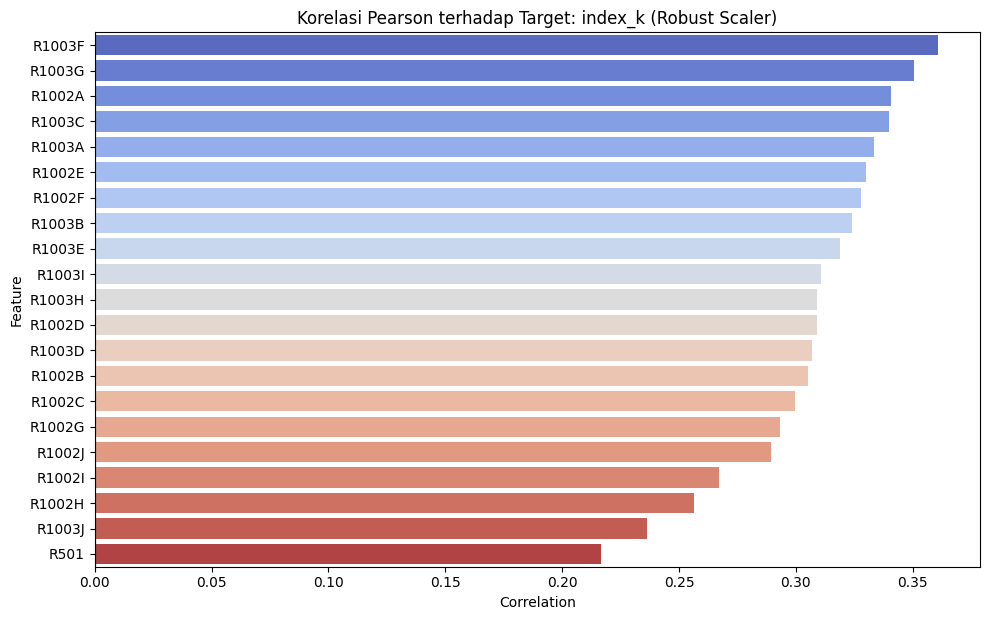

In [317]:
# Kolom yang ingin dikecualikan
excluded_cols = ['URUT', 'WEIGHT']

# Ambil hanya kolom yang bukan target atau excluded
cols_to_check = [col for col in df_final_robust.columns if col not in excluded_cols + ['index_k']]

# Hitung korelasi terhadap target
correlations = df_final_robust[cols_to_check].corrwith(df_final_robust['index_k'])

# Buat DataFrame dari hasil korelasi
corr_df = correlations.dropna().sort_values(ascending=False).reset_index()
corr_df.columns = ['Feature', 'Correlation']

# (Opsional) Filter hanya korelasi dengan |r| > threshold
threshold = 0.2
corr_df_filtered = corr_df[abs(corr_df['Correlation']) > threshold]

# Plot
plt.figure(figsize=(10, len(corr_df_filtered) * 0.3))
sns.barplot(data=corr_df_filtered, x='Correlation', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.title('Korelasi Pearson terhadap Target: index_k (Robust Scaler)')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()


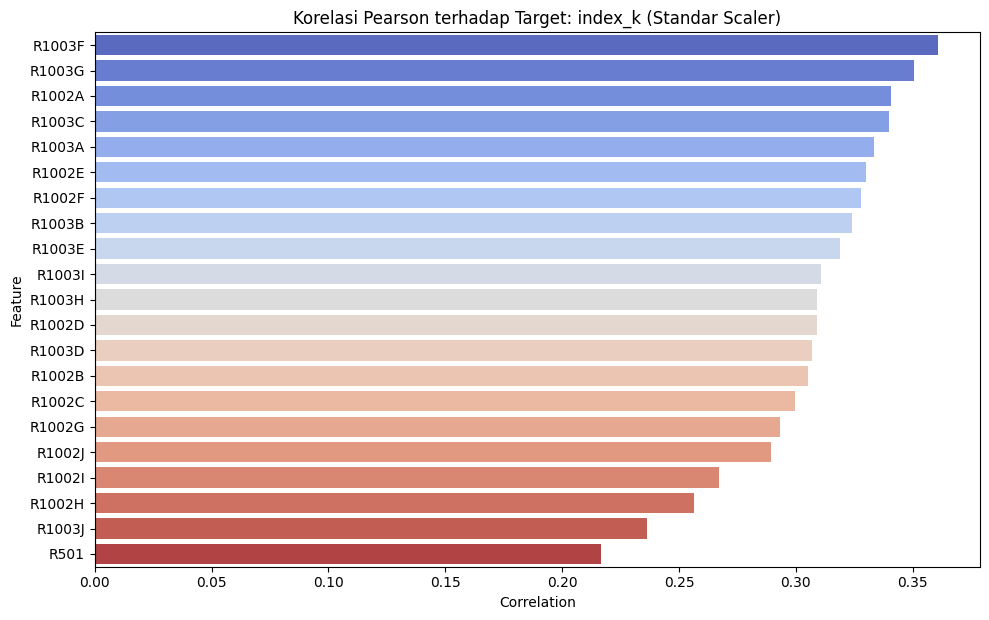

In [318]:
# Kolom yang ingin dikecualikan
excluded_cols = ['URUT', 'WEIGHT']

# Ambil hanya kolom yang bukan target atau excluded
cols_to_check = [col for col in df_final_robust.columns if col not in excluded_cols + ['index_k']]

# Hitung korelasi terhadap target
correlations = df_final_robust[cols_to_check].corrwith(df_final_robust['index_k'])

# Buat DataFrame dari hasil korelasi
corr_df = correlations.dropna().sort_values(ascending=False).reset_index()
corr_df.columns = ['Feature', 'Correlation']

# (Opsional) Filter hanya korelasi dengan |r| > threshold
threshold = 0.2
corr_df_filtered = corr_df[abs(corr_df['Correlation']) > threshold]

# Plot
plt.figure(figsize=(10, len(corr_df_filtered) * 0.3))
sns.barplot(data=corr_df_filtered, x='Correlation', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.title('Korelasi Pearson terhadap Target: index_k (Standar Scaler)')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()


### Korelasi Dengan Menggabungkan Prefix

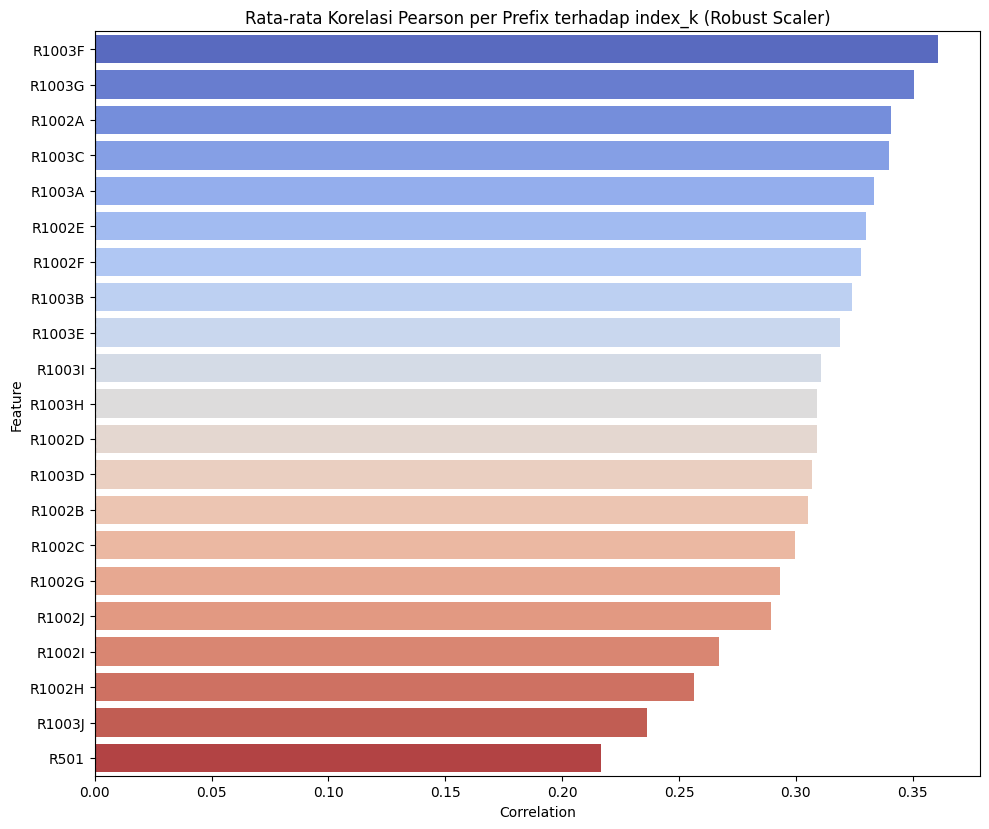

In [319]:
# Kolom yang ingin dikecualikan
excluded_cols = ['URUT', 'WEIGHT']

# Ambil hanya kolom yang bukan target atau excluded
cols_to_check = [col for col in df_final_robust.columns if col not in excluded_cols + ['index_k']]

# Buang kolom dengan std = 0 agar tidak error
df_valid = df_final_robust[cols_to_check].loc[:, df_final_robust[cols_to_check].std() > 0]

# Hitung korelasi terhadap target
correlations = df_valid.corrwith(df_final_robust['index_k'])

# Gabungkan nama fitur berdasarkan prefix sebelum underscore
grouped_corr = correlations.dropna().reset_index()
grouped_corr.columns = ['Feature', 'Correlation']
grouped_corr['Prefix'] = grouped_corr['Feature'].str.extract(r'^([^_]+)')

# Rata-rata korelasi per prefix
agg_corr = grouped_corr.groupby('Prefix')['Correlation'].mean().sort_values(ascending=False).reset_index()

# Filter berdasarkan threshold
threshold = 0.2
agg_corr_filtered = agg_corr[agg_corr['Correlation'].abs() > threshold]

# Plot
plt.figure(figsize=(10, len(agg_corr_filtered) * 0.4))
sns.barplot(data=corr_df_filtered, x='Correlation', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.title('Rata-rata Korelasi Pearson per Prefix terhadap index_k (Robust Scaler)')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

In [320]:
agg_corr

,Prefix,Correlation
0,R1003F,0.360765
1,R1003G,0.350376
2,R1002A,0.340565
3,R1003C,0.339810
4,R1003A,0.333379
...,...,...
248,R1303A,-0.169550
249,R609B,-0.183814
250,R606,-0.192336
251,R609A,-0.197559


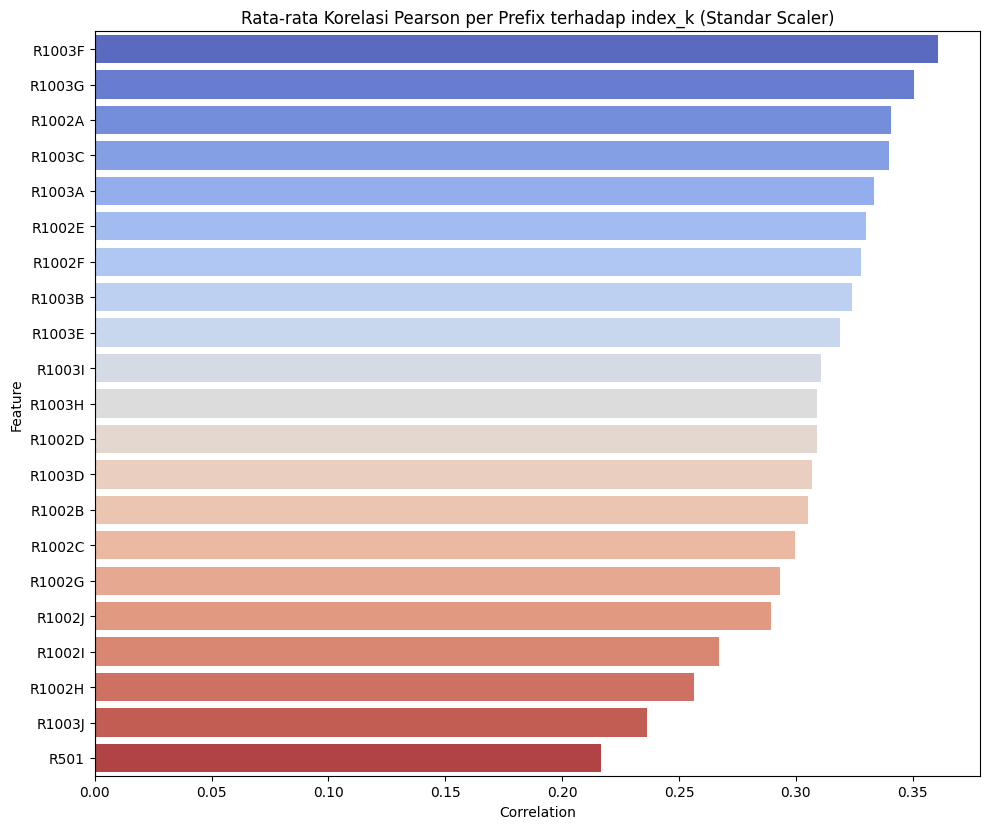

In [321]:
# Kolom yang ingin dikecualikan
excluded_cols = ['URUT', 'WEIGHT']

# Ambil hanya kolom yang bukan target atau excluded
cols_to_check = [col for col in df_final_robust.columns if col not in excluded_cols + ['index_k']]

# Buang kolom dengan std = 0 agar tidak error
df_valid = df_final_standard[cols_to_check].loc[:, df_final_robust[cols_to_check].std() > 0]

# Hitung korelasi terhadap target
correlations = df_valid.corrwith(df_final_robust['index_k'])

# Gabungkan nama fitur berdasarkan prefix sebelum underscore
grouped_corr = correlations.dropna().reset_index()
grouped_corr.columns = ['Feature', 'Correlation']
grouped_corr['Prefix'] = grouped_corr['Feature'].str.extract(r'^([^_]+)')

# Rata-rata korelasi per prefix
agg_corr = grouped_corr.groupby('Prefix')['Correlation'].mean().sort_values(ascending=False).reset_index()

# Filter berdasarkan threshold
threshold = 0.2
agg_corr_filtered = agg_corr[agg_corr['Correlation'].abs() > threshold]

# Plot
plt.figure(figsize=(10, len(agg_corr_filtered) * 0.4))
sns.barplot(data=corr_df_filtered, x='Correlation', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.title('Rata-rata Korelasi Pearson per Prefix terhadap index_k (Standar Scaler)')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# Modeling

In [322]:
df_model = df_final_robust.copy()
df_model

,R1301A,R1301B,R1301C,R1303A,R1303B,R1303C,R1305A,R1305B,R1305C,R1305D,...,R1103JK7_2,R1103JK7_3,R1103JK7_4,R1103JK7_5,R1103JK7_6,R1103JK7_7,R1103JK7_9,URUT,index_k,WEIGHT
0,0.0,0.0,-1.0,3.0,0.0,3.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,62.31,210.870377
1,0.0,1.0,0.0,3.0,0.0,1.0,3.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,72.21,210.870377
2,0.0,0.0,0.0,0.0,0.0,3.0,3.0,0.0,1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,70.80,210.870377
3,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,72.89,210.870377
4,0.0,0.0,0.0,3.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,72.34,210.870377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74679,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,74600,76.08,700.200012
74680,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,74618,67.29,399.394104
74681,0.0,1.0,0.0,2.0,0.0,2.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,74671,64.13,341.872620
74682,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,-2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,74673,71.23,341.872620


In [402]:
y = df_model['index_k']
y = np.log1p(y)
X = df_model.drop(columns=['WEIGHT', 'URUT', 'index_k'])

In [ ]:
y.describe()

count    74684.000000
mean         4.205198
std          0.108865
min          2.349469
25%          4.145671
50%          4.207524
75%          4.269697
max          4.615121
Name: index_k, dtype: float64

In [324]:
X

,R1301A,R1301B,R1301C,R1303A,R1303B,R1303C,R1305A,R1305B,R1305C,R1305D,...,R1103JK6_8,R1103JK6_9,R1103JK7_1,R1103JK7_2,R1103JK7_3,R1103JK7_4,R1103JK7_5,R1103JK7_6,R1103JK7_7,R1103JK7_9
0,0.0,0.0,-1.0,3.0,0.0,3.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,3.0,0.0,1.0,3.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,3.0,3.0,0.0,1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,3.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74679,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
74680,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
74681,0.0,1.0,0.0,2.0,0.0,2.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
74682,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,-2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [442]:
gbr = GradientBoostingRegressor(random_state=42)
rfr = RandomForestRegressor(n_jobs=-1, random_state=42)
dtr = DecisionTreeRegressor(random_state=42)

models = {
    "Gradient Boosting Regressor": gbr,
    "Random Forest Regressor": rfr,
    "Decision Tree Regressor": dtr
}

In [350]:
y

0        4.148043
1        4.293332
2        4.273884
3        4.302578
4        4.295106
           ...   
74679    4.344844
74680    4.223763
74681    4.176385
74682    4.279855
74683    4.009150
Name: index_k, Length: 74684, dtype: float64

## Uji Sampling Data

In [351]:
# Buat 10 bin dari target
bins = pd.qcut(y, q=10, labels=False, duplicates='drop')

X_500, _, y_500, _ = train_test_split(
    X, y,
    train_size=500,
    stratify=bins,
    random_state=42
)
X_1000, _, y_1000, _ = train_test_split(
    X, y,
    train_size=1000,
    stratify=bins,
    random_state=42
)
X_2000, _, y_2000, _ = train_test_split(
    X, y,
    train_size=2000,
    stratify=bins,
    random_state=42
)
X_3000, _, y_3000, _ = train_test_split(
    X, y,
    train_size=3000,
    stratify=bins,
    random_state=42
)
X_5000, _, y_5000, _ = train_test_split(
    X, y,
    train_size=5000,
    stratify=bins,
    random_state=42
)
X_7500, _, y_7500, _ = train_test_split(
    X, y,
    train_size=7500,
    stratify=bins,
    random_state=42
)
X_10000, _, y_10000, _ = train_test_split(
    X, y,
    train_size=10000,
    stratify=bins,
    random_state=42
)

data_uji = {
    "X_500": (X_500, y_500),
	"X_1000": (X_1000, y_1000),
	"X_2000": (X_2000, y_2000),
	"X_3000": (X_3000, y_3000),
	"X_5000": (X_5000, y_5000),
	"X_7500": (X_7500, y_7500),
	"X_10000": (X_10000, y_10000),
	"X_74684": (X, y)
}

In [ ]:
hasil_uji_sample = {}
for name, model_class in models.items(): # Changed 'model' to 'model_class' for clarity
    hasil_uji_sample[name] = {}
    for data_name, (X_data, y_data) in data_uji.items():
        # Create a new instance of the model for each dataset
        model = model_class.__class__() # This creates a fresh instance of the model

        X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
            X_data, y_data, test_size=0.2, random_state=42
        )

        time_start = time.time()
        model.fit(X_train_t, y_train_t)
        time_end = time.time()
        y_pred = model.predict(X_test_t)
        r2 = r2_score(y_test_t, y_pred)
        mse = mean_squared_error(y_test_t, y_pred)
        rmse = np.sqrt(mse)
        hasil_uji_sample[name][data_name] = {
            "R2": r2,
            "mse": mse,
            "rmse": rmse,
            "time": time_end - time_start
        }

In [375]:
hasil_uji_sample

{'Gradient Boosting Regressor': {'X_500': {'R2': 0.2516866555117411,
   'mse': 0.007031931407536413,
   'rmse': 0.0838566121873309,
   'time': 0.3713068962097168},
  'X_1000': {'R2': -0.06662087079566081,
   'mse': 0.012230599989330754,
   'rmse': 0.11059204306518057,
   'time': 0.7136201858520508},
  'X_2000': {'R2': 0.6701092751533386,
   'mse': 0.009362229286409006,
   'rmse': 0.09675861349982752,
   'time': 1.2742443084716797},
  'X_3000': {'R2': 0.35910691904233194,
   'mse': 0.006537953582011825,
   'rmse': 0.08085761301208332,
   'time': 1.8512115478515625},
  'X_5000': {'R2': 0.6134926130985925,
   'mse': 0.006580045002496152,
   'rmse': 0.08111747655404569,
   'time': 3.0995943546295166},
  'X_7500': {'R2': 0.47546858953365134,
   'mse': 0.007053327168051008,
   'rmse': 0.08398408877907176,
   'time': 4.690183639526367},
  'X_10000': {'R2': 0.5111563927082577,
   'mse': 0.00681013584978429,
   'rmse': 0.08252354724431257,
   'time': 6.286848783493042},
  'X_74684': {'R2': 0.47

In [353]:
max_r2 = -float('inf')  # Inisialisasi dengan nilai negatif tak hingga
best_model = None
best_dataset = None

for model_name, datasets in hasil_uji_sample.items():
    for dataset_name, metrics in datasets.items():
        current_r2 = metrics.get('R2') # Gunakan .get() untuk menghindari KeyError jika 'R2' tidak ada

        if current_r2 is not None and current_r2 > max_r2:
            max_r2 = current_r2
            best_model = model_name
            best_dataset = dataset_name

if best_model and best_dataset:
    print(f"R² Maksimum: {max_r2:.4f}")
    print(f"Model Terbaik: {best_model}")
    print(f"Dataset Terbaik (untuk R² ini): {best_dataset}")
else:
    print("Tidak ada data R² yang ditemukan atau hasil_uji_sample kosong.")


R² Maksimum: 0.6701
Model Terbaik: Gradient Boosting Regressor
Dataset Terbaik (untuk R² ini): X_2000


0.6872

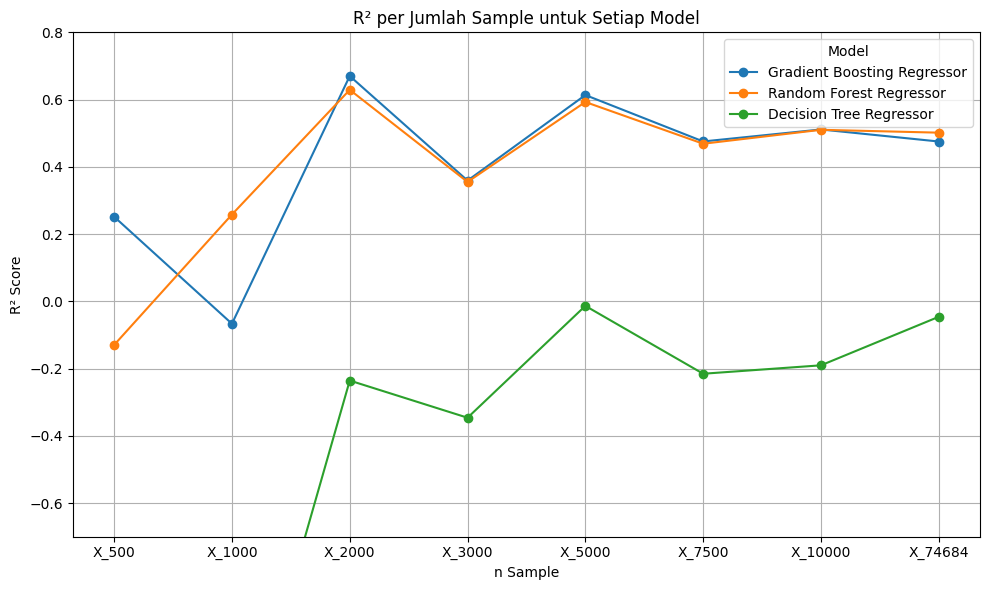

In [355]:
plt.figure(figsize=(10, 6))

# Plot R² untuk setiap model
for name, result in hasil_uji_sample.items():
    test_sizes = sorted(result.keys(), key=lambda x: int(x.split('_')[1]))
    r2_scores = [result[ts]['R2'] for ts in test_sizes]
    plt.plot(test_sizes, r2_scores, marker='o', label=name)

plt.title("R² per Jumlah Sample untuk Setiap Model")
plt.xlabel("n Sample")
plt.ylabel("R² Score")
plt.xticks(test_sizes)
plt.ylim(-0.7, (math.ceil(max_r2 * 10) / 10) + 0.1) 
plt.grid(True)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


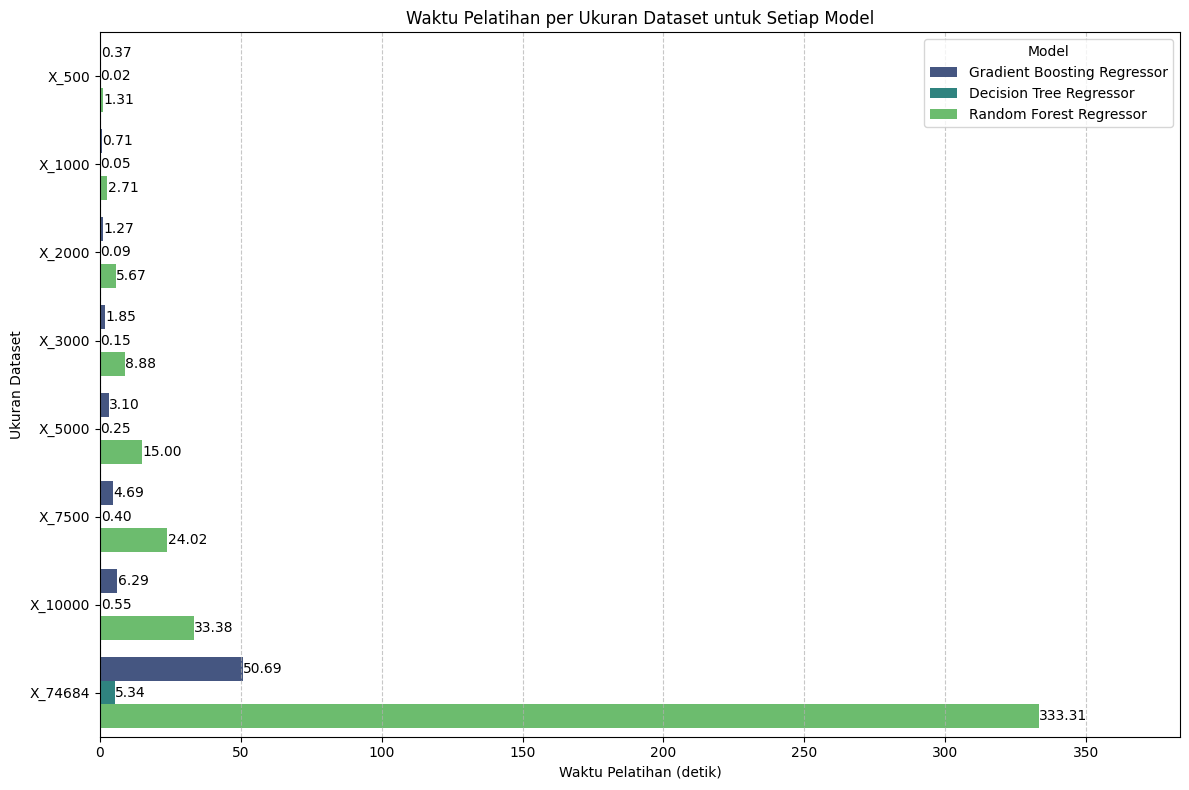

In [356]:
data_for_df = []
for model_name, datasets in hasil_uji_sample.items():
    for dataset_name, metrics in datasets.items():
        data_for_df.append({
            'Model': model_name,
            'Dataset': dataset_name,
            'Time': metrics['time'],
            'R2': metrics['R2'],
        })

df_sample = pd.DataFrame(data_for_df)

# Extract numerical part from 'Dataset' for proper sorting
df_sample['Dataset_Num'] = df_sample['Dataset'].apply(lambda x: int(x.split('_')[1]))

# Sort the DataFrame by Dataset_Num
df_sample = df_sample.sort_values(by='Dataset_Num')

plt.figure(figsize=(12, 8)) # Increased figure size for better readability

# Create the horizontal bar chart using seaborn
ax = sns.barplot(x='Time', y='Dataset', hue='Model', data=df_sample, palette='viridis')

plt.title("Waktu Pelatihan per Ukuran Dataset untuk Setiap Model")
plt.xlabel("Waktu Pelatihan (detik)")
plt.ylabel("Ukuran Dataset")
plt.grid(axis='x', linestyle='--', alpha=0.7) # Grid on x-axis for better readability of time
plt.legend(title="Model")
plt.tight_layout()

for container in ax.containers:
    # `container` adalah objek BarContainer untuk setiap kelompok hue (setiap model)
    for bar in container:
        # `bar` adalah objek Rectangle untuk setiap bar
        x_val = bar.get_width() # Lebar bar adalah nilai pada sumbu x
        y_val = bar.get_y() + bar.get_height() / 2 # Posisi y tengah bar
        ax.text(x_val + 0.05, y_val, f'{x_val:.2f}', va='center') # Tambahkan teks

# Sesuaikan batas xlim jika label terpotong
# Cari nilai maksimum waktu pelatihan untuk memperkirakan batas x
max_time = df_sample['Time'].max()
plt.xlim(0, max_time * 1.15)

plt.show()


In [357]:
df_sample.sort_values(by='R2', ascending=False, inplace=True)
df_sample

,Model,Dataset,Time,R2,Dataset_Num
2,Gradient Boosting Regressor,X_2000,1.274244,0.670109,2000
10,Random Forest Regressor,X_2000,5.672661,0.629068,2000
4,Gradient Boosting Regressor,X_5000,3.099594,0.613493,5000
12,Random Forest Regressor,X_5000,15.004790,0.592808,5000
6,Gradient Boosting Regressor,X_10000,6.286849,0.511156,10000
14,Random Forest Regressor,X_10000,33.375630,0.510146,10000
15,Random Forest Regressor,X_74684,333.310164,0.501630,74684
5,Gradient Boosting Regressor,X_7500,4.690184,0.475469,7500
7,Gradient Boosting Regressor,X_74684,50.687577,0.475301,74684
13,Random Forest Regressor,X_7500,24.019117,0.468702,7500


## Uji Test Split Data

In [358]:
X_2000.shape, y_2000.shape

((2000, 472), (2000,))

In [385]:
test_split_size = [0.1, 0.2, 0.3, 0.4]
hasil_split_train = {}
for name, model in models.items():
    hasil_split_train[name] = {}

    for test_size in test_split_size:
        if name == "Random Forest Regressor":
            model = model.__class__(n_jobs=-1, random_state=42)
        else:
            model = model.__class__(random_state=42)
        X_train_t2, X_test_t2, y_train_t2, y_test_t2 = train_test_split(
            X_2000, y_2000, test_size=test_size, random_state=42
        )
		
        model.fit(X_train_t2, y_train_t2)
        y_pred = model.predict(X_test_t2)

        mse = mean_squared_error(y_test_t2, y_pred)
        mae = mean_absolute_error(y_test_t2, y_pred)
        r2 = r2_score(y_test_t2, y_pred)

        hasil_split_train[name][test_size] = {
            'mse': mse,
            'mae': mae,
            'r2': r2
        }

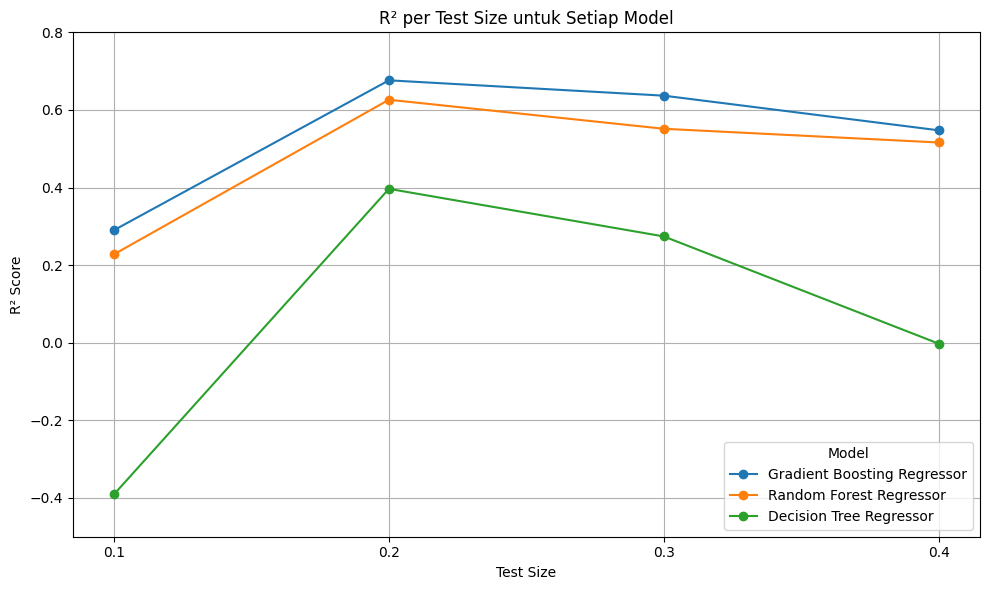

In [378]:
plt.figure(figsize=(10, 6))

# Plot R² untuk setiap model
for name, result in hasil_split_train.items():
    test_sizes = sorted(result.keys())
    r2_scores = [result[ts]['r2'] for ts in test_sizes]
    plt.plot(test_sizes, r2_scores, marker='o', label=name)

plt.title("R² per Test Size untuk Setiap Model")
plt.xlabel("Test Size")
plt.ylabel("R² Score")
plt.xticks(test_sizes)
plt.ylim(-0.5, 0.8)  # sesuaikan sesuai range R² Anda
plt.grid(True)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


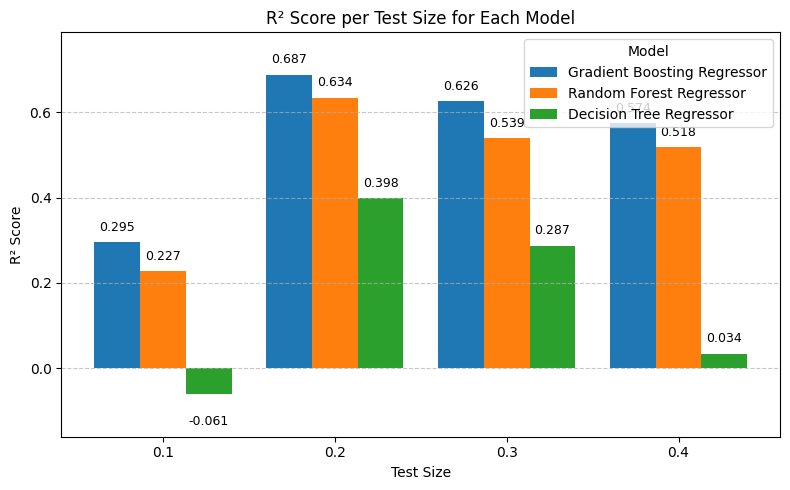

In [386]:
plt.figure(figsize=(8, 5)) # Slightly larger figure for better bar spacing

# Extract unique test sizes and model names
test_sizes = sorted(list(next(iter(hasil_split_train.values())).keys()))
model_names = list(hasil_split_train.keys())

# Set up positions for bars
n_models = len(model_names)
bar_width = 0.8 / n_models # Adjust bar width based on number of models
index = np.arange(len(test_sizes)) # Positions for groups of bars

for i, name in enumerate(model_names):
    r2_scores = [hasil_split_train[name][ts]['r2'] for ts in test_sizes]
    bar_positions = index + i * bar_width - (n_models - 1) * bar_width / 2

    bars = plt.bar(bar_positions, r2_scores, bar_width, label=name)
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + (0.02 if yval >= 0 else -0.05),
            f'{yval:.3f}', ha='center', va='bottom' if yval >= 0 else 'top', fontsize=9)


plt.title("R² Score per Test Size for Each Model")
plt.xlabel("Test Size")
plt.ylabel("R² Score")
plt.xticks(index, test_sizes) # Set x-axis ticks to the test sizes
# Adjust y-axis limits to accommodate negative R² and text labels
min_r2 = min(min(metrics['r2'] for metrics in res.values()) for res in hasil_split_train.values())
max_r2 = max(max(metrics['r2'] for metrics in res.values()) for res in hasil_split_train.values())
plt.ylim(min_r2 - 0.1, max_r2 + 0.1) # Add some padding

plt.grid(axis='y', linestyle='--', alpha=0.7) # Only y-axis grid for bar charts
plt.legend(title="Model", loc='best')
plt.tight_layout()
plt.show()

## Split Dataset

In [387]:
# split data untuk training dan testing dengan ukuran sample dan test size terbaik
X_train, X_test, y_train, y_test = train_test_split(
	X_2000, y_2000, test_size=0.2, random_state=42
)

## Base model

In [388]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape 

((1600, 472), (400, 472), (1600,), (400,))

In [419]:
base_dtr_model = DecisionTreeRegressor(random_state=42)
base_dtr_model.fit(X_train, y_train)
base_dtr_y_pred = base_dtr_model.predict(X_test)
r2_base_dtr = r2_score(y_test, base_dtr_y_pred)
mse_base_dtr = mean_squared_error(y_test, base_dtr_y_pred)
rmse_base_dtr = np.sqrt(mse_base_dtr)
mae_base_dtr = mean_absolute_error(y_test, base_dtr_y_pred)

# Tampilkan hasil optimasi pso
print(f"R² Score : {r2_base_dtr:.4f}")
print(f"MSE      : {mse_base_dtr:.4f}")
print(f"RMSE     : {rmse_base_dtr:.4f}")
print(f"MAE      : {mae_base_dtr:.4f}")

R² Score : 0.3983
MSE      : 0.0171
RMSE     : 0.1307
MAE      : 0.0989


In [422]:
print(base_dtr_model.max_depth)
print(base_dtr_model.min_samples_leaf)
print(base_dtr_model.min_samples_split)

None
1
2


In [395]:
base_rfr_model = RandomForestRegressor(n_jobs=-1,random_state=42)
base_rfr_model.fit(X_train, y_train)
base_rfr_y_pred = base_rfr_model.predict(X_test)
r2_base_rfr = r2_score(y_test, base_rfr_y_pred)
mse_base_rfr = mean_squared_error(y_test, base_rfr_y_pred)
rmse_base_rfr = np.sqrt(mse_base_rfr)
mae_base_rfr = mean_absolute_error(y_test, base_rfr_y_pred)

# Tampilkan hasil optimasi pso
print(f"R² Score : {r2_base_rfr:.4f}")
print(f"MSE      : {mse_base_rfr:.4f}")
print(f"RMSE     : {rmse_base_rfr:.4f}")
print(f"MAE      : {mae_base_rfr:.4f}")

R² Score : 0.6338
MSE      : 0.0104
RMSE     : 0.1019
MAE      : 0.0713


In [396]:
base_gbr_model = GradientBoostingRegressor(random_state=42)
base_gbr_model.fit(X_train,y_train)
base_gbr_y_pred = base_gbr_model.predict(X_test)
r2_base_gbr = r2_score(y_test, base_gbr_y_pred)
mse_base_gbr = mean_squared_error(y_test, base_gbr_y_pred)
rmse_base_gbr = np.sqrt(mse_base_gbr)
mae_base_gbr = mean_absolute_error(y_test, base_gbr_y_pred)

# Tampilkan hasil optimasi pso
print(f"R² Score : {r2_base_gbr:.4f}")
print(f"MSE      : {mse_base_gbr:.4f}")
print(f"RMSE     : {rmse_base_gbr:.4f}")
print(f"MAE      : {mae_base_gbr:.4f}")

R² Score : 0.6874
MSE      : 0.0089
RMSE     : 0.0942
MAE      : 0.0689


In [405]:
np.expm1(base_gbr_y_pred[0])

59.793290851091

In [397]:
base_model_score = {
	'Decision Tree Regressor' : {
		"r2": r2_base_dtr,
		'mse': mse_base_dtr,
		'rmse': rmse_base_dtr,
		'mae': mae_base_dtr
	},
	'Random Forest Regressor' : {
		"r2": r2_base_rfr,
		'mse': mse_base_rfr,
		'rmse': rmse_base_rfr,
		'mae': mae_base_rfr
	},
	'Gradient Boosting Regressor' : {
		"r2": r2_base_gbr,
		'mse': mse_base_gbr,
		'rmse': rmse_base_gbr,
		'mae': mae_base_gbr
	}
}

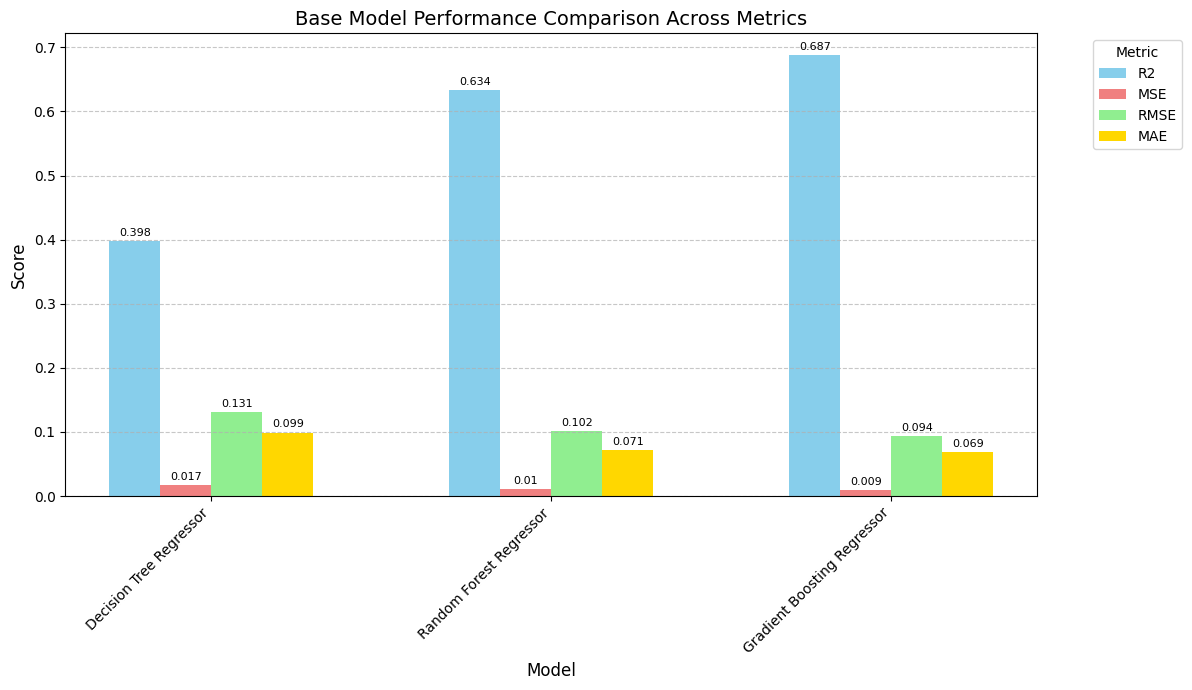

In [398]:
data_base_model = []
for model_name, metrics in base_model_score.items():
    for metric_name, score_value in metrics.items():
        data_base_model.append({'Model': model_name, 'Metric': metric_name.upper(), 'Score': score_value})

df_data_base_model = pd.DataFrame(data_base_model)

# Get unique models_name and metrics
models_name = df_data_base_model['Model'].unique()
metrics = df_data_base_model['Metric'].unique()

# Set up the bar chart
fig, ax = plt.subplots(figsize=(12, 7))

bar_width = 0.15
index = np.arange(len(models_name))

# Define colors for each metric for better readability
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']

# Plot bars for each metric and add labels
for i, metric in enumerate(metrics):
    metric_scores = [df_data_base_model[(df_data_base_model['Model'] == model) & (df_data_base_model['Metric'] == metric)]['Score'].iloc[0] for model in models_name]
    bars = ax.bar(index + i * bar_width, metric_scores, bar_width, label=metric, color=colors[i])

    # Add text labels on top of each bar
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 3), 
                ha='center', va='bottom', fontsize=8, color='black') # Adjust font size and color as needed

# Add labels, title, and legend
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Base Model Performance Comparison Across Metrics', fontsize=14)
ax.set_xticks(index + (len(metrics) - 1) * bar_width / 2)
ax.set_xticklabels(models_name, rotation=45, ha='right', fontsize=10) # Rotate labels to prevent overlap
ax.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping

# Save the plot
plt.savefig('base_model_performance_barchart.png')
plt.show()


## Hyperparamater Tunning (PSO)

### Decision Tree

In [406]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape 

((1600, 472), (400, 472), (1600,), (400,))

In [ ]:
def objectiveDT(params):
    results = []
    for p in params:
        min_samples_split = int(p[0]) 
        min_samples_leaf = int(p[1])
        
        model = DecisionTreeRegressor(
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        score = cross_val_score(model, X_train, y_train, scoring='r2', cv=KFold(n_splits=5, shuffle=True, random_state=42))
        results.append(-np.mean(score))
    return np.array(results)

In [ ]:
# Batas bawah dan atas
dt_lb = np.array([1, 1])
dt_ub = np.array([10, 10])
dt_bounds = (dt_lb, dt_ub)

# Parameter PSO
dt_options = {'c1': 0.5, 'c2': 0.5, 'w': 0.5}

# Inisialisasi optimizer
dt_optimizer = ps.single.GlobalBestPSO(
    n_particles=20,
    dimensions=2,
    options=dt_options,
    bounds=dt_bounds
)

# Jalankan optimasi
dt_best_score, dt_best_params = dt_optimizer.optimize(objectiveDT, iters=30)

# Cetak hasil
print("Best parameters:", dt_best_params)
print("Best R2 CV score:", -dt_best_score)

2025-07-20 21:20:30,934 - pyswarms.single.global_best - INFO - Optimize for 1 iters with {'c1': 0.5, 'c2': 0.5, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|1/1, best_cost=1.25
2025-07-20 21:20:39,039 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 1.2485023310815788, best pos: [4.3250305  5.54418702]


Best parameters: [4.3250305  5.54418702]
Best R2 CV score: -1.2485023310815788


24.4s

In [452]:
models["Decision Tree Regressor"]

DecisionTreeRegressor(random_state=42)

In [ ]:
models["Decision Tree Regressor"].set_params(min_samples_split=2,min_samples_leaf=1)
models["Decision Tree Regressor"].fit(X_train, y_train)
dt_y_pred = models["Decision Tree Regressor"].predict(X_test)

DecisionTreeRegressor(random_state=42)

DecisionTreeRegressor(random_state=42)

In [ ]:
pso_rf_model = DecisionTreeRegressor(
	min_samples_split=int(dt_best_params[0]),
	min_samples_leaf=int(dt_best_params[1]),
	random_state=42
)
pso_rf_model.fit(X_train, y_train)
dt_y_pred = pso_rf_model.predict(X_test)
r2_dtr = r2_score(y_test, dt_y_pred)
mse_dtr = mean_squared_error(y_test, dt_y_pred)
rmse_dtr = np.sqrt(mse_dtr)
mae_dtr = mean_absolute_error(y_test, dt_y_pred)

# Tampilkan hasil optimasi pso
print(f"R² Score : {r2_dtr:.4f}")
print(f"MSE      : {mse_dtr:.4f}")
print(f"RMSE     : {rmse_dtr:.4f}")
print(f"MAE      : {mae_dtr:.4f}")


R² Score : 0.2393
MSE      : 0.0216
RMSE     : 0.1469
MAE      : 0.0935


In [466]:
test_rf_model = DecisionTreeRegressor(
	min_samples_split=2,
	min_samples_leaf=1,
	random_state=42
)
test_rf_model.fit(X_train, y_train)
dt_y_pred_test = test_rf_model.predict(X_test)
r2_dtr_test = r2_score(y_test, dt_y_pred_test)
mse_dtr_test = mean_squared_error(y_test, dt_y_pred_test)
rmse_dtr_test = np.sqrt(mse_dtr_test)
mae_dtr_test = mean_absolute_error(y_test, dt_y_pred_test)

# Tampilkan hasil optimasi test
print(f"R² Score : {r2_dtr_test:.4f}")
print(f"MSE      : {mse_dtr_test:.4f}")
print(f"RMSE     : {rmse_dtr_test:.4f}")
print(f"MAE      : {mae_dtr_test:.4f}")


R² Score : 0.3983
MSE      : 0.0171
RMSE     : 0.1307
MAE      : 0.0989


### Random Forest

In [468]:
def objectiveRF(params):
    results = []
    for p in params:
        n_estimators = int(p[0])
        max_depth = int(p[1])
        
        model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42,
            n_jobs=-1
        )
        score = cross_val_score(model, X_2000, y_2000, scoring='r2', cv=KFold(n_splits=5, shuffle=True, random_state=42))
        results.append(-np.mean(score))
    return np.array(results)

In [469]:
# Batas parameter
# [n_estimators, max_depth]
rf_bounds = ([100, 10], [300, 30])

# Inisialisasi optimizer
rf_optimizer = ps.single.GlobalBestPSO(
    n_particles=20,
    dimensions=2,
    options={'c1': 0.5, 'c2': 0.5, 'w': 0.5},
    bounds=rf_bounds
)

In [470]:
rf_best_cost, rf_best_pos = rf_optimizer.optimize(objectiveRF, iters=30)

2025-07-20 21:24:43,962 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 0.5, 'c2': 0.5, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|30/30, best_cost=-0.342
2025-07-20 22:31:16,608 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -0.3421622523681833, best pos: [144.47550634  22.26882898]


66m 32.6s

In [471]:
# Cetak hasil
print("Best parameters:", rf_best_pos)
print("Best R2 CV score:", -rf_best_cost)

Best parameters: [144.47550634  22.26882898]
Best R2 CV score: 0.3421622523681833


In [472]:
models['Random Forest Regressor']

RandomForestRegressor(n_jobs=-1, random_state=42)

In [473]:
# models['Random Forest Regressor'].set_params(n_estimators=int(best_pos[0]), max_depth=int(best_pos[1]))
models['Random Forest Regressor'].set_params(n_estimators=int(rf_best_pos[0]), max_depth=int(rf_best_pos[1]), random_state=42)

RandomForestRegressor(max_depth=22, n_estimators=144, n_jobs=-1,
                      random_state=42)

In [479]:
models['Random Forest Regressor'].fit(X_train, y_train)

RandomForestRegressor(max_depth=22, n_estimators=144, n_jobs=-1,
                      random_state=42)

In [480]:
rf_y_pred = models["Random Forest Regressor"].predict(X_test)

In [481]:
r2_rfr = r2_score(y_test, rf_y_pred)
mse_rfr = mean_squared_error(y_test, rf_y_pred)
rmse_rfr = np.sqrt(mse_rfr)
mae_rfr = mean_absolute_error(y_test, rf_y_pred)

# Tampilkan hasil optimasi pso
print(f"R² Score : {r2_rfr:.4f}")
print(f"MSE      : {mse_rfr:.4f}")
print(f"RMSE     : {rmse_rfr:.4f}")
print(f"MAE      : {mae_rfr:.4f}")

R² Score : 0.6336
MSE      : 0.0104
RMSE     : 0.1020
MAE      : 0.0713


In [ ]:
model_rfr_base = RandomForestRegressor(
    # n_estimators=int(rf_best_pos[0]),
	# max_depth=int(rf_best_pos[1]),
	random_state=42,
	n_jobs=-1
)
model_rfr_base.fit(X_train, y_train)
rfr_y_pred_t = model_rfr_base.predict(X_test)

r2_rfr_test = r2_score(y_test, rfr_y_pred_t)
mse_rfr_test = mean_squared_error(y_test, rfr_y_pred_t)
rmse_rfr_test = np.sqrt(mse_rfr_test)
mae_rfr_test = mean_absolute_error(y_test, rfr_y_pred_t)

print(f"R² Score : {r2_rfr_test:.4f}")
print(f"MSE      : {mse_rfr_test:.4f}")
print(f"RMSE     : {rmse_rfr_test:.4f}")
print(f"MAE      : {mae_rfr_test:.4f}")

R² Score : 0.6338
MSE      : 0.0104
RMSE     : 0.1019
MAE      : 0.0713


### Gradient Boosting Regressor

In [356]:
X_2000.shape ,y_2000.shape 

((2000, 472), (2000,))

In [482]:
def objectiveGBR(params):
    results = []
    for p in params:
        n_estimators = int(p[0])
        max_depth = int(p[1])
        learning_rate = round(p[2], 1)
        
        model = GradientBoostingRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            random_state=42
        )
        score = cross_val_score(model, X_2000, y_2000, scoring='r2', cv=KFold(n_splits=5, shuffle=True, random_state=42))
        results.append(-np.mean(score))
    return np.array(results)

# Batas parameter
# [n_estimators, max_depth, learning rate]
gbr_bounds = ([50, 2, 0.1], [150, 5, 0.3])
# gbr_bounds = ([50], [150])

# Inisialisasi optimizer
gbr_optimizer = ps.single.GlobalBestPSO(
    n_particles=20,
    dimensions=3,
    # dimensions=1,
    options={'c1': 0.5, 'c2': 0.5, 'w': 0.5},
    bounds=gbr_bounds
)

In [483]:
gbr_best_cost, gbr_best_pos = gbr_optimizer.optimize(objectiveGBR, iters=30)

2025-07-20 22:33:56,743 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 0.5, 'c2': 0.5, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|30/30, best_cost=-0.401
2025-07-20 23:29:51,324 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -0.40081437272728593, best pos: [120.24676502   2.9323658    0.14786811]


In [484]:
print('n_estimators=',int(gbr_best_pos[0]))
print('max_depth=',int(gbr_best_pos[1]))
print('learning_rate=',round(gbr_best_pos[2],1))

n_estimators= 120
max_depth= 2
learning_rate= 0.1


55m 54.5s

In [485]:
models['Gradient Boosting Regressor'].set_params(n_estimators=int(gbr_best_pos[0]), max_depth=int(gbr_best_pos[1]),learning_rate=round(gbr_best_pos[2], 1),random_state=42)

GradientBoostingRegressor(max_depth=2, n_estimators=120, random_state=42)

In [486]:
print(f"Default max_depth: {models['Gradient Boosting Regressor'].max_depth}")
print(f"Default learning_rate: {models['Gradient Boosting Regressor'].learning_rate}")
print(f"Default n_estimators: {models['Gradient Boosting Regressor'].n_estimators}")

Default max_depth: 2
Default learning_rate: 0.1
Default n_estimators: 120


In [525]:
models['Gradient Boosting Regressor'].fit(X_train,y_train)

GradientBoostingRegressor(max_depth=2, n_estimators=120, random_state=42)

In [526]:
gbr_y_pred = models['Gradient Boosting Regressor'].predict(X_test)
r2_gbr = r2_score(y_test, gbr_y_pred)
mse_gbr = mean_squared_error(y_test, gbr_y_pred)
rmse_gbr = np.sqrt(mse_gbr)
mae_gbr = mean_absolute_error(y_test, gbr_y_pred)

# Tampilkan hasil optimasi pso
print(f"R² Score : {r2_gbr:.4f}")
print(f"MSE      : {mse_gbr:.4f}")
print(f"RMSE     : {rmse_gbr:.4f}")
print(f"MAE      : {mae_gbr:.4f}")

R² Score : 0.6929
MSE      : 0.0087
RMSE     : 0.0934
MAE      : 0.0684


In [527]:
model_gbr_base = GradientBoostingRegressor(random_state=42)
print(f"Default max_depth: {model_gbr_base.max_depth}")
print(f"Default learning_rate: {model_gbr_base.learning_rate}")
print(f"Default n_estimators: {model_gbr_base.n_estimators}")
print(f"Default min_samples_split: {model_gbr_base.min_samples_split}")

Default max_depth: 3
Default learning_rate: 0.1
Default n_estimators: 100
Default min_samples_split: 2


In [528]:
model_gbr_base.fit(X_train, y_train)
gbr_y_pred_t = model_gbr_base.predict(X_test)

r2_gbr_test = r2_score(y_test, gbr_y_pred_t)
mse_gbr_test = mean_squared_error(y_test, gbr_y_pred_t)
rmse_gbr_test = np.sqrt(mse_gbr_test)
mae_gbr_test = mean_absolute_error(y_test, gbr_y_pred_t)

# Tampilkan hasil optimasi pso
print(f"R² Score : {r2_gbr_test:.4f}")
print(f"MSE      : {mse_gbr_test:.4f}")
print(f"RMSE     : {rmse_gbr_test:.4f}")
print(f"MAE      : {mae_gbr_test:.4f}")

R² Score : 0.6874
MSE      : 0.0089
RMSE     : 0.0942
MAE      : 0.0689


In [492]:
model_gbr_test = GradientBoostingRegressor(
	random_state=42,
	n_estimators=125,
	max_depth=3,
	learning_rate=0.1,
	min_samples_leaf= 4,
)
model_gbr_test.fit(X_train, y_train)
gbr_y_pred_t = model_gbr_test.predict(X_test)

r2_gbr_test = r2_score(y_test, gbr_y_pred_t)
mse_gbr_test = mean_squared_error(y_test, gbr_y_pred_t)
rmse_gbr_test = np.sqrt(mse_gbr_test)
mae_gbr_test = mean_absolute_error(y_test, gbr_y_pred_t)

# Tampilkan hasil optimasi pso
print(f"R² Score : {r2_gbr_test:.4f}")
print(f"MSE      : {mse_gbr_test:.4f}")
print(f"RMSE     : {rmse_gbr_test:.4f}")
print(f"MAE      : {mae_gbr_test:.4f}")

R² Score : 0.6830
MSE      : 0.0090
RMSE     : 0.0949
MAE      : 0.0689


## Model Terbaik

## Validasi 5 KfoldCV

In [493]:
models['Decision Tree Regressor']

DecisionTreeRegressor(random_state=42)

In [494]:
models['Random Forest Regressor']

RandomForestRegressor(max_depth=22, n_estimators=144, n_jobs=-1,
                      random_state=42)

In [506]:
models['Gradient Boosting Regressor']
# print(f"Default max_depth: {models['Gradient Boosting Regressor'].max_depth}")
# print(f"Default learning_rate: {models['Gradient Boosting Regressor'].learning_rate}")
# print(f"Default n_estimators: {models['Gradient Boosting Regressor'].n_estimators}")

GradientBoostingRegressor(max_depth=2, n_estimators=120, random_state=42)

In [541]:
hasil_kfold = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
	r2_scores = cross_val_score(model, X_2000, y_2000, cv=kf, scoring='r2', n_jobs=-1)
	hasil_kfold[name] = {
		'r2_scores': r2_scores,
		'r2_mean': np.mean(r2_scores),
		'r2_std': np.std(r2_scores),
	}


In [542]:
hasil_kfold

{'Gradient Boosting Regressor': {'r2_scores': array([0.69286196, 0.39735388, 0.35955773, 0.21695229, 0.33734601]),
  'r2_mean': 0.40081437272728593,
  'r2_std': 0.15801226278015845},
 'Random Forest Regressor': {'r2_scores': array([0.6303719 , 0.31702801, 0.27412833, 0.12084122, 0.36844181]),
  'r2_mean': 0.3421622523681829,
  'r2_std': 0.16613172953900215},
 'Decision Tree Regressor': {'r2_scores': array([ 0.39821359, -0.36017527, -0.27508582, -0.59548405, -0.86723867]),
  'r2_mean': -0.33995404397513,
  'r2_std': 0.4225713904988988}}

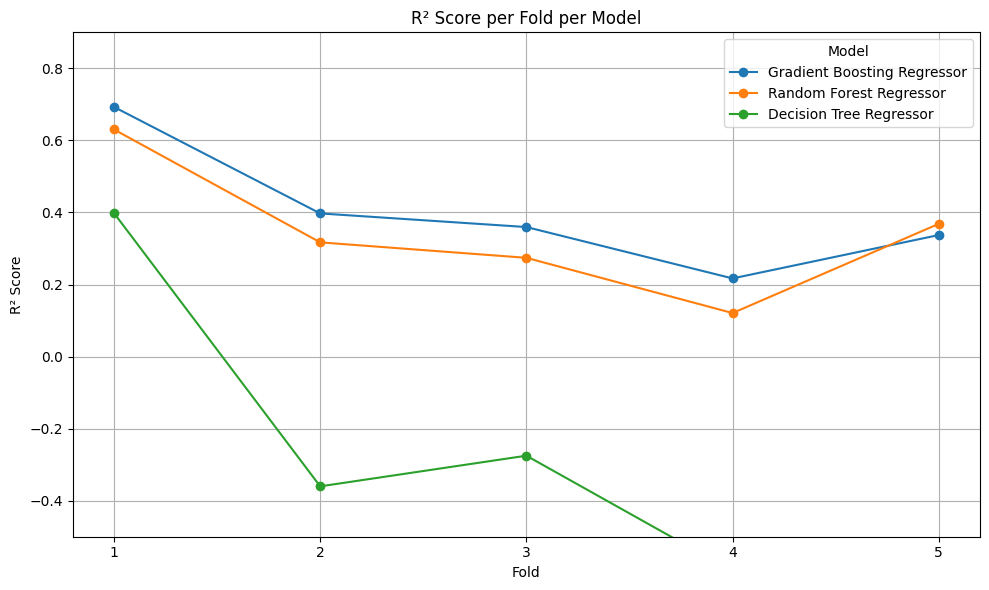

In [545]:
plt.figure(figsize=(10, 6))

# Asumsikan hasil_kfold sudah berisi 'r2_scores' (list of 5 scores per model)
for name, metrics in hasil_kfold.items():
    r2_scores = metrics['r2_scores']
    plt.plot(range(1, len(r2_scores) + 1), r2_scores, marker='o', label=name)

plt.title("R² Score per Fold per Model")
plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.xticks(range(1, 6))  # fold 1 to 5
plt.ylim(- 0.5, 0.9)           # optional, adjust based on your values
plt.grid(True)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


In [546]:
hasil_kfold

{'Gradient Boosting Regressor': {'r2_scores': array([0.69286196, 0.39735388, 0.35955773, 0.21695229, 0.33734601]),
  'r2_mean': 0.40081437272728593,
  'r2_std': 0.15801226278015845},
 'Random Forest Regressor': {'r2_scores': array([0.6303719 , 0.31702801, 0.27412833, 0.12084122, 0.36844181]),
  'r2_mean': 0.3421622523681829,
  'r2_std': 0.16613172953900215},
 'Decision Tree Regressor': {'r2_scores': array([ 0.39821359, -0.36017527, -0.27508582, -0.59548405, -0.86723867]),
  'r2_mean': -0.33995404397513,
  'r2_std': 0.4225713904988988}}

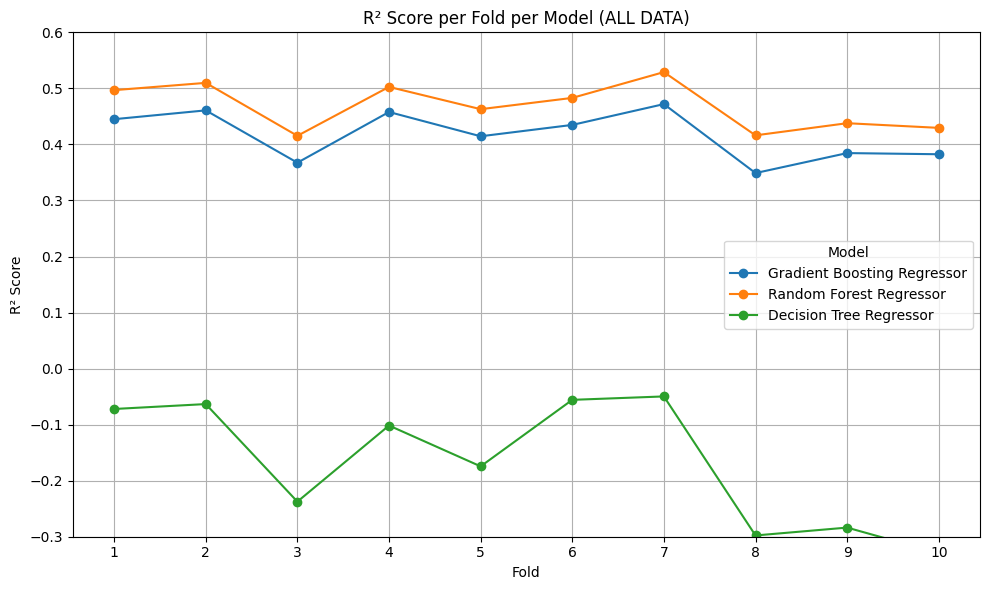

In [544]:
hasil_kfold_a = {}
kf = KFold(n_splits=10, shuffle=True, random_state=42)
for name, model in models.items():
	r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2', n_jobs=-1)
	hasil_kfold_a[name] = {
		'r2_scores': r2_scores,
		'r2_mean': np.mean(r2_scores),
		'r2_std': np.std(r2_scores),
	}
plt.figure(figsize=(10, 6))


In [ ]:
# Asumsikan hasil_kfold_a sudah berisi 'r2_scores' (list of 5 scores per model)
for name, metrics in hasil_kfold_a.items():
    r2_scores = metrics['r2_scores']
    plt.plot(range(1, len(r2_scores) + 1), r2_scores, marker='o', label=name)

plt.title("R² Score per Fold per Model (ALL DATA)")
plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.xticks(range(1, 11))  # fold 1 to 5
plt.ylim(-0.3, 0.6)           # optional, adjust based on your values
plt.grid(True)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


In [539]:
hasil_kfold_a

{'Decision Tree Regressor': {'r2_scores': array([0.44501423, 0.46074907, 0.36738131, 0.45783936, 0.41452696,
         0.43480789, 0.47192286, 0.34888961, 0.38454665, 0.38246693]),
  'r2_mean': 0.41681448746273364,
  'r2_std': 0.04129508288849744}}

## Shap

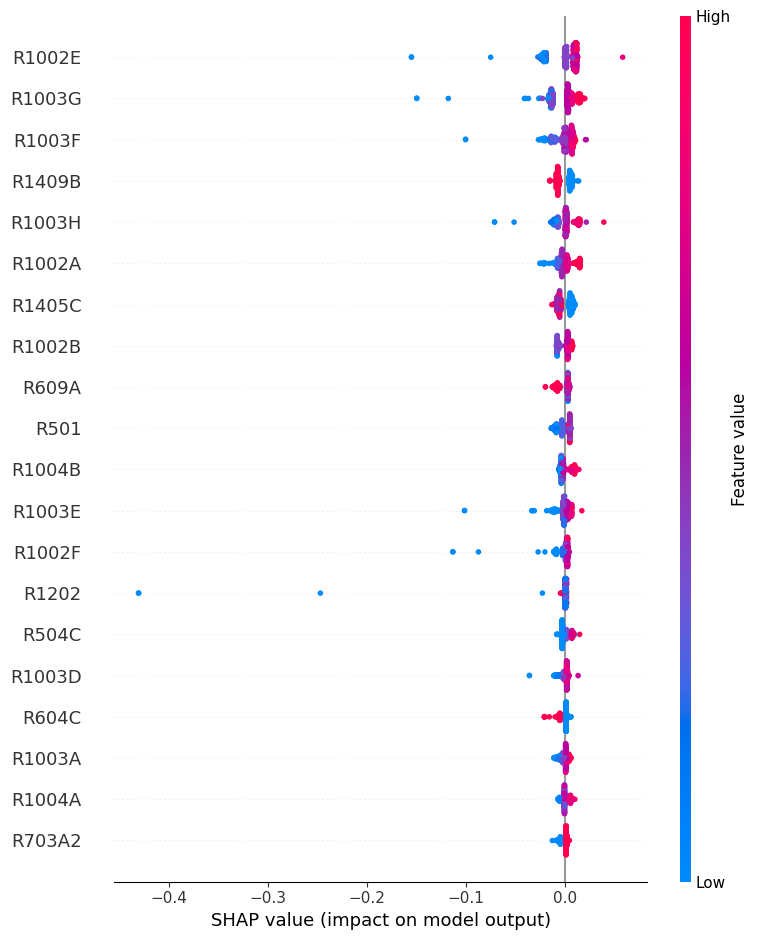

In [511]:
# SHAP explanation
explainer = shap.Explainer(models['Gradient Boosting Regressor'])  # model.predict for tree-based regressor
X_test_sample = X_test.sample(n=400, random_state=42)
shap_values = explainer(X_test_sample)
# Plot summary
shap.summary_plot(shap_values, X_test_sample)

## Visualisi Perbandingan model terbaik dengan base model

## Feature Importance

In [513]:
feature_importances = models['Gradient Boosting Regressor'].feature_importances_
feature_names = X_2000.columns # Get column names from your DataFrame

# Create a DataFrame for better organization and sorting
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# print("\n--- 50 Fitur Teratas Berdasarkan Importansi (Gradient Boosting Regressor) ---")
# print(importance_df.head(50).to_string(index=False))

In [514]:
importance_df

,Feature,Importance
198,R1202,0.127618
129,R1002E,0.103786
136,R1003B,0.071125
141,R1003G,0.067268
139,R1003E,0.056854
...,...,...
207,R1210B,0.000000
206,R1210A,0.000000
205,R1209,0.000000
203,R1207,0.000000


In [515]:
grouped_importance = importance_df.copy()
grouped_importance['Prefix'] = grouped_importance['Feature'].str.extract(r'^([^_]+)')

# Rata-rata korelasi per prefix
agg_importance = grouped_importance.groupby('Prefix')['Importance'].sum().sort_values(ascending=False).reset_index()

In [516]:
grouped_importance

,Feature,Importance,Prefix
198,R1202,0.127618,R1202
129,R1002E,0.103786,R1002E
136,R1003B,0.071125,R1003B
141,R1003G,0.067268,R1003G
139,R1003E,0.056854,R1003E
...,...,...,...
207,R1210B,0.000000,R1210B
206,R1210A,0.000000,R1210A
205,R1209,0.000000,R1209
203,R1207,0.000000,R1207


In [518]:
agg_importance

,Prefix,Importance
0,R1202,0.127618
1,R1002E,0.103786
2,R1003B,0.071125
3,R1003G,0.067268
4,R1003E,0.056854
...,...,...
248,R1405A,0.000000
249,R1405B,0.000000
250,R1101B3,0.000000
251,R1103EK7,0.000000


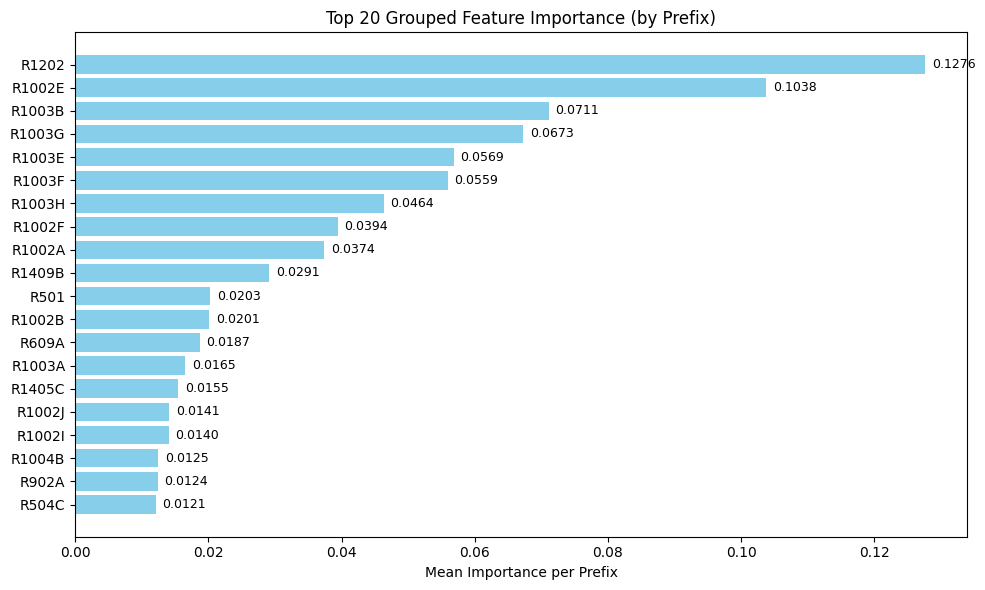

In [519]:
top_20 = agg_importance.sort_values(by='Importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(top_20['Prefix'], top_20['Importance'], color='skyblue')

# Tambahkan label (angka importance) di ujung batang
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001,              # posisi horizontal (sedikit di kanan ujung batang)
		bar.get_y() + bar.get_height() / 2,  # posisi vertikal (tengah batang)
		f'{width:.4f}',             # format importance
		va='center', fontsize=9)

plt.xlabel('Mean Importance per Prefix')
plt.title('Top 20 Grouped Feature Importance (by Prefix)')
plt.gca().invert_yaxis()  # supaya nilai paling tinggi di atas
plt.tight_layout()
plt.show()

In [536]:
selected_feature = []
def train_with_top_prefixes(feature_names, prefix_importance_df, top_n_list=[20, 50, 100, 'ALL']):
    results = []
    # Extract prefix untuk semua fitur
    feature_prefix_map = {f: f.split('_')[0] if '_' in f else f for f in feature_names}
    prefix_to_features = {}
    for f, p in feature_prefix_map.items():
        prefix_to_features.setdefault(p, []).append(f)

    for top_n in top_n_list:
        if top_n == 'ALL':
            selected_prefixes = prefix_importance_df['Prefix'].tolist()
        else:
            selected_prefixes = prefix_importance_df.head(top_n)['Prefix'].tolist()
        
        # Ambil semua fitur yang memiliki prefix tersebut
        selected_features = [f for f in feature_names if feature_prefix_map[f] in selected_prefixes]

        # Subset data
        X_sub = X_2000[selected_features]

        # Split data
        from sklearn.model_selection import train_test_split
        X_train, X_test, y_train, y_test = train_test_split(X_sub, y_2000, test_size=0.2, random_state=42)

        # Train model
        model = GradientBoostingRegressor(random_state=42, n_estimators=120, max_depth=2, learning_rate=0.1)
        
        time_start = time.time()
        model.fit(X_train, y_train)
        time_end = time.time()

        # Predict dan evaluasi
        y_pred = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        results.append({
            'Top_N_Prefix': top_n,
            'Num_Features': len(selected_features),
            'RMSE': rmse,
            'R2': r2,
            'time': time_end - time_start,
        })
        selected_feature.append({
            'Top_N_Prefix': top_n,
            'Num_Features': len(selected_features),
            'selected_features': selected_features
		})

    return pd.DataFrame(results)

# --- 3. Jalankan
df_result_fi = train_with_top_prefixes(feature_names, agg_importance)

In [537]:
df_result_fi

,Top_N_Prefix,Num_Features,RMSE,R2,time
0,20,20,0.092826,0.696378,0.239054
1,50,68,0.093125,0.694422,0.356177
2,100,170,0.094828,0.683140,0.607832
3,ALL,472,0.093362,0.692862,1.007102


## Final Model

## Visualisi Akhir

## Export Model